# Weight candlestick comparison (layer + granular)

This notebook compares two model sources that can be either:
- Hugging Face model IDs, or
- local checkpoint files/directories.

It provides:
1. **Layer-level view** (all blocks aggregated per layer index)
2. **Granular across-layer view** where each x-tick is `(layer, component)`:
   `L0:attention`, `L0:mlp`, ..., up to the last common layer.

Candlestick definition:
- Wick = min/max **excluding outliers**
- Body = mean +/- `BODY_SIGMA` * std
- Mean line = horizontal segment in the body
- Outliers = points beyond `OUTLIER_SIGMA` * std


In [ ]:
import gc
import os
import re
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.patches import Rectangle
from transformers import AutoModel

try:
    import dotenv

    dotenv.load_dotenv()
except Exception:
    pass

In [ ]:
# ---- Model sources (HF id OR local checkpoint path OR local checkpoint directory) ----
MODEL_A = "/media/hdd1_4TB/dansolombrino/cache/PARA/Projects/quantization/qat-transfer/storage/checkpoints/vision/ilharco_hf_clip/fp/openai_clip_vit_base_patch16/CIFAR10/optim=adamw_lr=1e-05_wd=0.1_ls=0.0_wl=500_mgn=1.0_bs=128"
MODEL_B = "/media/hdd1_4TB/dansolombrino/cache/PARA/Projects/quantization/qat-transfer/storage/checkpoints/vision/ilharco_timm_supervised/fp/vit_base_patch16_224_augreg2_in21k_ft_in1k/CIFAR10/optim=adamw_lr=1e-05_wd=0.1_ls=0.0_wl=500_mgn=1.0_bs=128"
MODEL_A_LABEL = "openai_clip"
MODEL_B_LABEL = "timm_vit"


# ---- General knobs ----
TRUST_REMOTE_CODE = False
OUTLIER_SIGMA = 2.0
BODY_SIGMA = 1.0
MAX_OUTLIERS_PER_CANDLE = 1900
INCLUDE_UNINDEXED_PARAMETERS = False
DPI = 180

SAVE_LAYER_FIG_PATH = None
SAVE_GRANULAR_ACROSS_FIG_PATH = None
SAVE_GRANULAR_SINGLE_LAYER_FIG_PATH = None

# ---- Component matching mode ----
# "family" -> attention/mlp/norm/embedding/projection/misc
# "path"   -> normalized path tail after layer index
COMPONENT_MATCH_MODE = "family"
MAX_COMPONENT_LABEL_CHARS = 36

# ---- Granular plotting controls ----
PLOT_GRANULAR_ACROSS_ALL_LAYERS = True
PLOT_GRANULAR_SINGLE_LAYER = False
LAYER_INDEX_TO_INSPECT = None  # e.g. 5

In [ ]:
_LAYER_CONTAINER_NAMES = {"layers", "layer", "blocks", "block", "resblocks", "stages", "h"}
_PARAM_TAIL_TOKENS = {"weight", "bias", "running_mean", "running_var", "num_batches_tracked"}
_CKPT_NAME_RE = re.compile(r"_(\\d+)\\.pt$")


def _find_layer_index_and_tail_start(segments: List[str]) -> Tuple[Optional[int], Optional[int]]:
    for i, seg in enumerate(segments[:-1]):
        if seg in _LAYER_CONTAINER_NAMES and i + 1 < len(segments) and segments[i + 1].isdigit():
            return int(segments[i + 1]), i + 2
        if seg in {"encoder", "decoder", "transformer"} and i + 2 < len(segments):
            if segments[i + 1] in _LAYER_CONTAINER_NAMES and segments[i + 2].isdigit():
                return int(segments[i + 2]), i + 3
    for i, seg in enumerate(segments):
        if seg.isdigit():
            return int(seg), i + 1
    return None, None


def _strip_parameter_suffix(path_segments: List[str]) -> List[str]:
    stripped = [s.lower() for s in path_segments]
    while stripped and stripped[-1] in _PARAM_TAIL_TOKENS:
        stripped.pop()
    return stripped


def _normalize_component_name(path_segments: List[str], mode: str = "family") -> str:
    core = _strip_parameter_suffix(path_segments)
    if not core:
        return "misc"
    if mode == "path":
        return ".".join(core)
    if any(("attn" in seg) or ("attention" in seg) for seg in core):
        return "attention"
    if any(
        ("mlp" in seg)
        or ("ffn" in seg)
        or ("feedforward" in seg)
        or ("feed_forward" in seg)
        or ("intermediate" in seg)
        for seg in core
    ):
        return "mlp"
    if any(("norm" in seg) or seg.startswith("ln") for seg in core):
        return "norm"
    if any("embed" in seg for seg in core):
        return "embedding"
    if any("proj" in seg for seg in core):
        return "projection"
    return core[0]


def _extract_epoch(filename: str) -> int:
    m = _CKPT_NAME_RE.search(filename)
    return int(m.group(1)) if m else -1


def _checkpoint_priority(filename: str) -> int:
    if filename.startswith("classifier_epoch_"):
        return 0
    if filename.startswith("epoch_"):
        return 1
    if filename.startswith("encoder_epoch_"):
        return 2
    return 9


def _resolve_checkpoint_from_directory(directory: Path) -> Path:
    candidates: List[Path] = []
    for p in directory.rglob("*.pt"):
        if not p.is_file():
            continue
        name = p.name
        if name.startswith("head_epoch_") or name == "head.pt":
            continue
        candidates.append(p)

    if not candidates:
        raise FileNotFoundError(f"No usable .pt checkpoint found under: {directory}")

    candidates.sort(
        key=lambda p: (
            _checkpoint_priority(p.name),
            -_extract_epoch(p.name),
            -p.stat().st_mtime,
            str(p),
        )
    )
    return candidates[0]


def resolve_model_source(model_source: str) -> Tuple[str, str]:
    expanded = os.path.expanduser(model_source)
    path = Path(expanded)
    if path.exists():
        if path.is_file():
            if path.suffix != ".pt":
                raise ValueError(f"Local file is not a .pt checkpoint: {path}")
            return "checkpoint", str(path)
        if path.is_dir():
            ckpt = _resolve_checkpoint_from_directory(path)
            return "checkpoint", str(ckpt)
    return "hf", model_source


def _load_named_tensors_from_checkpoint(checkpoint_path: str) -> List[Tuple[str, torch.Tensor]]:
    payload = torch.load(checkpoint_path, map_location="cpu")
    if isinstance(payload, dict):
        state_dict = payload
    elif hasattr(payload, "state_dict"):
        state_dict = payload.state_dict()
    else:
        raise TypeError(f"Unsupported checkpoint payload type: {type(payload)}")

    named_tensors: List[Tuple[str, torch.Tensor]] = []
    for name, value in state_dict.items():
        if torch.is_tensor(value):
            named_tensors.append((name, value))
    return named_tensors


def _load_named_tensors_from_hf(model_id: str) -> List[Tuple[str, torch.Tensor]]:
    model = AutoModel.from_pretrained(model_id, trust_remote_code=TRUST_REMOTE_CODE)
    model.eval()
    named_tensors = [(name, param.detach().cpu()) for name, param in model.named_parameters()]
    del model
    gc.collect()
    return named_tensors


def collect_grouped_parameter_blocks(
    named_tensors: List[Tuple[str, torch.Tensor]],
    component_mode: str = "family",
) -> Tuple[Dict[int, List[np.ndarray]], Dict[int, Dict[str, List[np.ndarray]]], int]:
    grouped_by_layer: Dict[int, List[np.ndarray]] = defaultdict(list)
    grouped_by_component: Dict[int, Dict[str, List[np.ndarray]]] = defaultdict(
        lambda: defaultdict(list)
    )
    skipped_unindexed = 0

    for name, param in named_tensors:
        if not torch.is_tensor(param):
            continue
        if not torch.is_floating_point(param):
            continue

        segments = name.split(".")
        layer_idx, tail_start = _find_layer_index_and_tail_start(segments)

        if layer_idx is None:
            if INCLUDE_UNINDEXED_PARAMETERS:
                layer_idx = -1
                tail_start = 0
            else:
                skipped_unindexed += 1
                continue

        tail_segments = segments[tail_start:] if tail_start is not None else []
        component_name = _normalize_component_name(tail_segments, mode=component_mode)

        values = param.detach().cpu().float().reshape(-1).numpy()
        grouped_by_layer[layer_idx].append(values)
        grouped_by_component[layer_idx][component_name].append(values)

    grouped_by_component_plain = {
        layer_idx: dict(comp_map) for layer_idx, comp_map in grouped_by_component.items()
    }
    return dict(grouped_by_layer), grouped_by_component_plain, skipped_unindexed


def compute_distribution_statistics(blocks: List[np.ndarray]) -> Dict[str, object]:
    values = np.concatenate(blocks)

    mean = float(values.mean())
    std = float(values.std())
    min_value = float(values.min())
    max_value = float(values.max())

    if std == 0.0:
        outlier_mask = np.zeros(values.shape, dtype=bool)
    else:
        lower = mean - OUTLIER_SIGMA * std
        upper = mean + OUTLIER_SIGMA * std
        outlier_mask = (values < lower) | (values > upper)

    outliers = values[outlier_mask]
    inliers = values[~outlier_mask]

    if inliers.size == 0:
        wick_min = min_value
        wick_max = max_value
    else:
        wick_min = float(inliers.min())
        wick_max = float(inliers.max())

    if MAX_OUTLIERS_PER_CANDLE is not None and outliers.size > MAX_OUTLIERS_PER_CANDLE:
        rng = np.random.default_rng(0)
        outliers = rng.choice(outliers, size=MAX_OUTLIERS_PER_CANDLE, replace=False)

    body_half = BODY_SIGMA * std
    return {
        "min": min_value,
        "max": max_value,
        "mean": mean,
        "std": std,
        "wick_min": wick_min,
        "wick_max": wick_max,
        "body_low": mean - body_half,
        "body_high": mean + body_half,
        "outliers": outliers,
        "n_values": int(values.size),
    }


def compute_layer_statistics(
    grouped_by_layer: Dict[int, List[np.ndarray]],
) -> Dict[int, Dict[str, object]]:
    stats: Dict[int, Dict[str, object]] = {}
    for layer_idx, blocks in sorted(grouped_by_layer.items()):
        layer_stats = compute_distribution_statistics(blocks)
        layer_stats["n_blocks"] = len(blocks)
        stats[layer_idx] = layer_stats
    return stats


def compute_component_statistics(
    grouped_by_component: Dict[int, Dict[str, List[np.ndarray]]],
) -> Dict[int, Dict[str, Dict[str, object]]]:
    stats: Dict[int, Dict[str, Dict[str, object]]] = {}
    for layer_idx, component_map in sorted(grouped_by_component.items()):
        stats[layer_idx] = {}
        for component_name, blocks in sorted(component_map.items()):
            component_stats = compute_distribution_statistics(blocks)
            component_stats["n_blocks"] = len(blocks)
            stats[layer_idx][component_name] = component_stats
    return stats


def load_model_statistics(
    model_source: str,
    component_mode: str = "family",
) -> Tuple[Dict[int, Dict[str, object]], Dict[int, Dict[str, Dict[str, object]]], int, str, str]:
    source_kind, resolved_source = resolve_model_source(model_source)
    if source_kind == "checkpoint":
        print(f"Loading local checkpoint: {resolved_source}")
        named_tensors = _load_named_tensors_from_checkpoint(resolved_source)
    else:
        print(f"Loading Hugging Face model: {resolved_source}")
        named_tensors = _load_named_tensors_from_hf(resolved_source)

    grouped_by_layer, grouped_by_component, skipped_unindexed = collect_grouped_parameter_blocks(
        named_tensors,
        component_mode=component_mode,
    )

    layer_stats = compute_layer_statistics(grouped_by_layer)
    component_stats = compute_component_statistics(grouped_by_component)

    return layer_stats, component_stats, skipped_unindexed, source_kind, resolved_source


def _draw_single_candlestick(
    ax,
    x_center: float,
    stats: Dict[str, object],
    edge_color: str,
    face_color: str,
    width: float,
    jitter_seed: int,
) -> None:
    ax.vlines(
        x_center, stats["wick_min"], stats["wick_max"], color=edge_color, linewidth=1.3, zorder=2
    )
    cap_half = width * 0.30
    ax.hlines(
        stats["wick_min"],
        x_center - cap_half,
        x_center + cap_half,
        color=edge_color,
        linewidth=1.3,
        zorder=2,
    )
    ax.hlines(
        stats["wick_max"],
        x_center - cap_half,
        x_center + cap_half,
        color=edge_color,
        linewidth=1.3,
        zorder=2,
    )

    body_low = stats["body_low"]
    body_high = stats["body_high"]
    body_height = max(body_high - body_low, 1e-12)
    body = Rectangle(
        (x_center - width / 2, body_low),
        width,
        body_height,
        facecolor=face_color,
        edgecolor=edge_color,
        linewidth=1.2,
        alpha=0.9,
        zorder=3,
    )
    ax.add_patch(body)

    ax.hlines(
        stats["mean"],
        x_center - width / 2,
        x_center + width / 2,
        color=edge_color,
        linewidth=2.0,
        zorder=4,
    )

    outliers = stats["outliers"]
    if outliers.size > 0:
        rng = np.random.default_rng(jitter_seed)
        jitter = rng.uniform(-width * 0.35, width * 0.35, size=outliers.size)
        ax.scatter(
            np.full(outliers.shape, x_center) + jitter,
            outliers,
            s=8,
            c=edge_color,
            alpha=0.25,
            linewidths=0,
            zorder=1,
        )


def _order_component_names(component_names: List[str]) -> List[str]:
    preferred = ["attention", "mlp", "norm", "embedding", "projection", "misc"]
    rank = {name: idx for idx, name in enumerate(preferred)}
    return sorted(component_names, key=lambda n: (rank.get(n, len(preferred)), n))


def _truncate_label(label: str, max_chars: int) -> str:
    if len(label) <= max_chars:
        return label
    return label[: max_chars - 3] + "..."


def plot_weight_candlesticks(
    stats_a: Dict[int, Dict[str, object]],
    stats_b: Dict[int, Dict[str, object]],
    model_a_name: str,
    model_b_name: str,
    ordered_layer_indices: List[int],
) -> None:
    n_layers = len(ordered_layer_indices)
    fig, ax = plt.subplots(figsize=(max(16, 0.65 * n_layers), 9), dpi=DPI)

    width = 0.32
    x_positions = np.arange(n_layers, dtype=float)
    styles = [
        (stats_a, model_a_name, "#1f77b4", "#9ecae1", -width / 1.6, 1),
        (stats_b, model_b_name, "#d62728", "#fcbba1", width / 1.6, 2),
    ]

    global_min = min(min(stats_a[i]["min"], stats_b[i]["min"]) for i in ordered_layer_indices)
    global_max = max(max(stats_a[i]["max"], stats_b[i]["max"]) for i in ordered_layer_indices)
    y_margin = max((global_max - global_min) * 0.05, 1e-6)

    for axis_idx, layer_idx in enumerate(ordered_layer_indices):
        for model_stats, _, edge, face, x_offset, jitter_offset in styles:
            x_center = x_positions[axis_idx] + x_offset
            _draw_single_candlestick(
                ax,
                x_center=x_center,
                stats=model_stats[layer_idx],
                edge_color=edge,
                face_color=face,
                width=width,
                jitter_seed=(axis_idx + 1) * 1000 + jitter_offset,
            )

    ax.set_ylim(global_min - y_margin, global_max + y_margin)
    ax.set_xlim(-0.8, n_layers - 0.2)
    ax.set_xlabel("Layer (common ordering)", fontsize=12)
    ax.set_ylabel("Weight value", fontsize=12)
    ax.set_title(
        f"Layer weight distribution candlesticks\\n{model_a_name} vs {model_b_name}\\n"
        f"Wick=min/max excluding outliers, body=mean+/-{BODY_SIGMA} sigma, points=outliers beyond {OUTLIER_SIGMA} sigma",
        fontsize=13,
    )
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    labels = [f"Layer {i}" for i in range(1, n_layers + 1)]
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, rotation=90 if n_layers > 20 else 45, ha="right")

    handles = [
        Rectangle((0, 0), 1, 1, facecolor=styles[0][3], edgecolor=styles[0][2], label=model_a_name),
        Rectangle((0, 0), 1, 1, facecolor=styles[1][3], edgecolor=styles[1][2], label=model_b_name),
    ]
    ax.legend(handles=handles, loc="upper right")

    plt.tight_layout()
    if SAVE_LAYER_FIG_PATH:
        fig.savefig(SAVE_LAYER_FIG_PATH, dpi=DPI, bbox_inches="tight")
        print(f"Saved figure to: {SAVE_LAYER_FIG_PATH}")
    plt.show()


def collect_granular_pairs_across_layers(
    component_stats_a: Dict[int, Dict[str, Dict[str, object]]],
    component_stats_b: Dict[int, Dict[str, Dict[str, object]]],
    ordered_layer_indices: List[int],
) -> List[Tuple[int, str]]:
    pairs: List[Tuple[int, str]] = []
    for layer_idx in ordered_layer_indices:
        components_a = set(component_stats_a.get(layer_idx, {}))
        components_b = set(component_stats_b.get(layer_idx, {}))
        common_components = _order_component_names(list(components_a & components_b))
        for component_name in common_components:
            pairs.append((layer_idx, component_name))
    return pairs


def plot_component_candlesticks_across_layers(
    component_stats_a: Dict[int, Dict[str, Dict[str, object]]],
    component_stats_b: Dict[int, Dict[str, Dict[str, object]]],
    model_a_name: str,
    model_b_name: str,
    ordered_layer_indices: List[int],
) -> None:
    pairs = collect_granular_pairs_across_layers(
        component_stats_a, component_stats_b, ordered_layer_indices
    )
    if not pairs:
        raise RuntimeError("No common (layer, component) pairs found for granular plotting.")

    n_pairs = len(pairs)
    fig, ax = plt.subplots(figsize=(max(18, 0.5 * n_pairs), 9), dpi=DPI)

    width = 0.30
    x_positions = np.arange(n_pairs, dtype=float)
    styles = [
        (component_stats_a, model_a_name, "#1f77b4", "#9ecae1", -width / 1.7, 11),
        (component_stats_b, model_b_name, "#d62728", "#fcbba1", width / 1.7, 29),
    ]

    global_min = min(
        min(component_stats_a[layer_idx][name]["min"], component_stats_b[layer_idx][name]["min"])
        for layer_idx, name in pairs
    )
    global_max = max(
        max(component_stats_a[layer_idx][name]["max"], component_stats_b[layer_idx][name]["max"])
        for layer_idx, name in pairs
    )
    y_margin = max((global_max - global_min) * 0.07, 1e-6)

    for pair_idx, (layer_idx, component_name) in enumerate(pairs):
        for model_stats, _, edge, face, x_offset, jitter_offset in styles:
            x_center = x_positions[pair_idx] + x_offset
            _draw_single_candlestick(
                ax,
                x_center=x_center,
                stats=model_stats[layer_idx][component_name],
                edge_color=edge,
                face_color=face,
                width=width,
                jitter_seed=(pair_idx + 1) * 100 + jitter_offset,
            )

    previous_layer = pairs[0][0]
    for pair_idx, (layer_idx, _) in enumerate(pairs):
        if pair_idx > 0 and layer_idx != previous_layer:
            ax.axvline(pair_idx - 0.5, color="gray", linewidth=0.8, alpha=0.35)
            previous_layer = layer_idx

    ax.set_ylim(global_min - y_margin, global_max + y_margin)
    ax.set_xlim(-0.8, n_pairs - 0.2)
    ax.set_xlabel("Each x-tick is one (layer, component) pair", fontsize=12)
    ax.set_ylabel("Weight value", fontsize=12)
    ax.set_title(
        f"Granular comparison across all layers\\n{model_a_name} vs {model_b_name} | component mode={COMPONENT_MATCH_MODE}\\n"
        f"For each layer x: attention_x vs attention_x, mlp_x vs mlp_x, norm_x vs norm_x, ...",
        fontsize=13,
    )
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    labels = [f"L{layer_idx}:{component_name}" for layer_idx, component_name in pairs]
    labels = [_truncate_label(lbl, MAX_COMPONENT_LABEL_CHARS) for lbl in labels]
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, rotation=90 if n_pairs > 14 else 45, ha="right")

    handles = [
        Rectangle((0, 0), 1, 1, facecolor=styles[0][3], edgecolor=styles[0][2], label=model_a_name),
        Rectangle((0, 0), 1, 1, facecolor=styles[1][3], edgecolor=styles[1][2], label=model_b_name),
    ]
    ax.legend(handles=handles, loc="upper right")

    plt.tight_layout()
    if SAVE_GRANULAR_ACROSS_FIG_PATH:
        fig.savefig(SAVE_GRANULAR_ACROSS_FIG_PATH, dpi=DPI, bbox_inches="tight")
        print(f"Saved figure to: {SAVE_GRANULAR_ACROSS_FIG_PATH}")
    plt.show()


def plot_component_candlesticks_for_layer(
    component_stats_a: Dict[int, Dict[str, Dict[str, object]]],
    component_stats_b: Dict[int, Dict[str, Dict[str, object]]],
    model_a_name: str,
    model_b_name: str,
    layer_idx: int,
) -> None:
    components_a = set(component_stats_a.get(layer_idx, {}))
    components_b = set(component_stats_b.get(layer_idx, {}))
    common_components = _order_component_names(list(components_a & components_b))
    if not common_components:
        raise RuntimeError(f"No common components found at layer index {layer_idx}.")

    n_components = len(common_components)
    fig, ax = plt.subplots(figsize=(max(12, 1.1 * n_components), 8), dpi=DPI)

    width = 0.34
    x_positions = np.arange(n_components, dtype=float)
    styles = [
        (component_stats_a, model_a_name, "#1f77b4", "#9ecae1", -width / 1.6, 11),
        (component_stats_b, model_b_name, "#d62728", "#fcbba1", width / 1.6, 29),
    ]

    global_min = min(
        min(component_stats_a[layer_idx][c]["min"], component_stats_b[layer_idx][c]["min"])
        for c in common_components
    )
    global_max = max(
        max(component_stats_a[layer_idx][c]["max"], component_stats_b[layer_idx][c]["max"])
        for c in common_components
    )
    y_margin = max((global_max - global_min) * 0.07, 1e-6)

    for comp_axis_idx, component_name in enumerate(common_components):
        for model_stats, _, edge, face, x_offset, jitter_offset in styles:
            x_center = x_positions[comp_axis_idx] + x_offset
            _draw_single_candlestick(
                ax,
                x_center=x_center,
                stats=model_stats[layer_idx][component_name],
                edge_color=edge,
                face_color=face,
                width=width,
                jitter_seed=(layer_idx + 1) * 10000 + (comp_axis_idx + 1) * 100 + jitter_offset,
            )

    ax.set_ylim(global_min - y_margin, global_max + y_margin)
    ax.set_xlim(-0.8, n_components - 0.2)
    ax.set_xlabel(f"Components at layer index {layer_idx}", fontsize=12)
    ax.set_ylabel("Weight value", fontsize=12)
    ax.set_title(
        f"Single-layer granular component comparison at layer {layer_idx}\\n"
        f"{model_a_name} vs {model_b_name} | component mode={COMPONENT_MATCH_MODE}",
        fontsize=13,
    )
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    truncated_labels = [_truncate_label(c, MAX_COMPONENT_LABEL_CHARS) for c in common_components]
    ax.set_xticks(x_positions)
    ax.set_xticklabels(truncated_labels, rotation=45 if n_components <= 12 else 70, ha="right")

    handles = [
        Rectangle((0, 0), 1, 1, facecolor=styles[0][3], edgecolor=styles[0][2], label=model_a_name),
        Rectangle((0, 0), 1, 1, facecolor=styles[1][3], edgecolor=styles[1][2], label=model_b_name),
    ]
    ax.legend(handles=handles, loc="upper right")

    plt.tight_layout()
    if SAVE_GRANULAR_SINGLE_LAYER_FIG_PATH:
        fig.savefig(SAVE_GRANULAR_SINGLE_LAYER_FIG_PATH, dpi=DPI, bbox_inches="tight")
        print(f"Saved figure to: {SAVE_GRANULAR_SINGLE_LAYER_FIG_PATH}")
    plt.show()

In [ ]:
layer_stats_a, component_stats_a, skipped_a, kind_a, resolved_a = load_model_statistics(
    MODEL_A,
    component_mode=COMPONENT_MATCH_MODE,
)
layer_stats_b, component_stats_b, skipped_b, kind_b, resolved_b = load_model_statistics(
    MODEL_B,
    component_mode=COMPONENT_MATCH_MODE,
)

print(f"\nResolved A ({kind_a}): {resolved_a}")
print(f"Resolved B ({kind_b}): {resolved_b}")

common_layer_indices = sorted(set(layer_stats_a) & set(layer_stats_b))
if not common_layer_indices:
    raise RuntimeError("No common numbered layers were found between the two model sources.")

print(f"\nCommon numbered layers: {len(common_layer_indices)}")
print(f"Skipped unindexed parameters in A: {skipped_a}")
print(f"Skipped unindexed parameters in B: {skipped_b}")

print(
    "\nAxis label -> original layer index, block counts, and common granular components (first 20):"
)
for axis_idx, layer_idx in enumerate(common_layer_indices[:20], start=1):
    common_components = sorted(
        set(component_stats_a.get(layer_idx, {})) & set(component_stats_b.get(layer_idx, {}))
    )
    print(
        f"Layer {axis_idx:>2} -> index {layer_idx:>3} | "
        f"blocks A/B: {layer_stats_a[layer_idx]['n_blocks']}/{layer_stats_b[layer_idx]['n_blocks']} | "
        f"common components: {len(common_components)}"
    )

Loading local checkpoint: /media/hdd1_4TB/dansolombrino/cache/PARA/Projects/quantization/qat-transfer/storage/checkpoints/vision/ilharco_hf_clip/fp/openai_clip_vit_base_patch16/CIFAR10/optim=adamw_lr=1e-05_wd=0.1_ls=0.0_wl=500_mgn=1.0_bs=128/seed=2038/epoch_6.pt
Loading local checkpoint: /media/hdd1_4TB/dansolombrino/cache/PARA/Projects/quantization/qat-transfer/storage/checkpoints/vision/ilharco_timm_supervised/fp/vit_base_patch16_224_augreg2_in21k_ft_in1k/CIFAR10/optim=adamw_lr=1e-05_wd=0.1_ls=0.0_wl=500_mgn=1.0_bs=128/seed=2038/classifier_epoch_6.pt

Resolved A (checkpoint): /media/hdd1_4TB/dansolombrino/cache/PARA/Projects/quantization/qat-transfer/storage/checkpoints/vision/ilharco_hf_clip/fp/openai_clip_vit_base_patch16/CIFAR10/optim=adamw_lr=1e-05_wd=0.1_ls=0.0_wl=500_mgn=1.0_bs=128/seed=2038/epoch_6.pt
Resolved B (checkpoint): /media/hdd1_4TB/dansolombrino/cache/PARA/Projects/quantization/qat-transfer/storage/checkpoints/vision/ilharco_timm_supervised/fp/vit_base_patch16_224_au

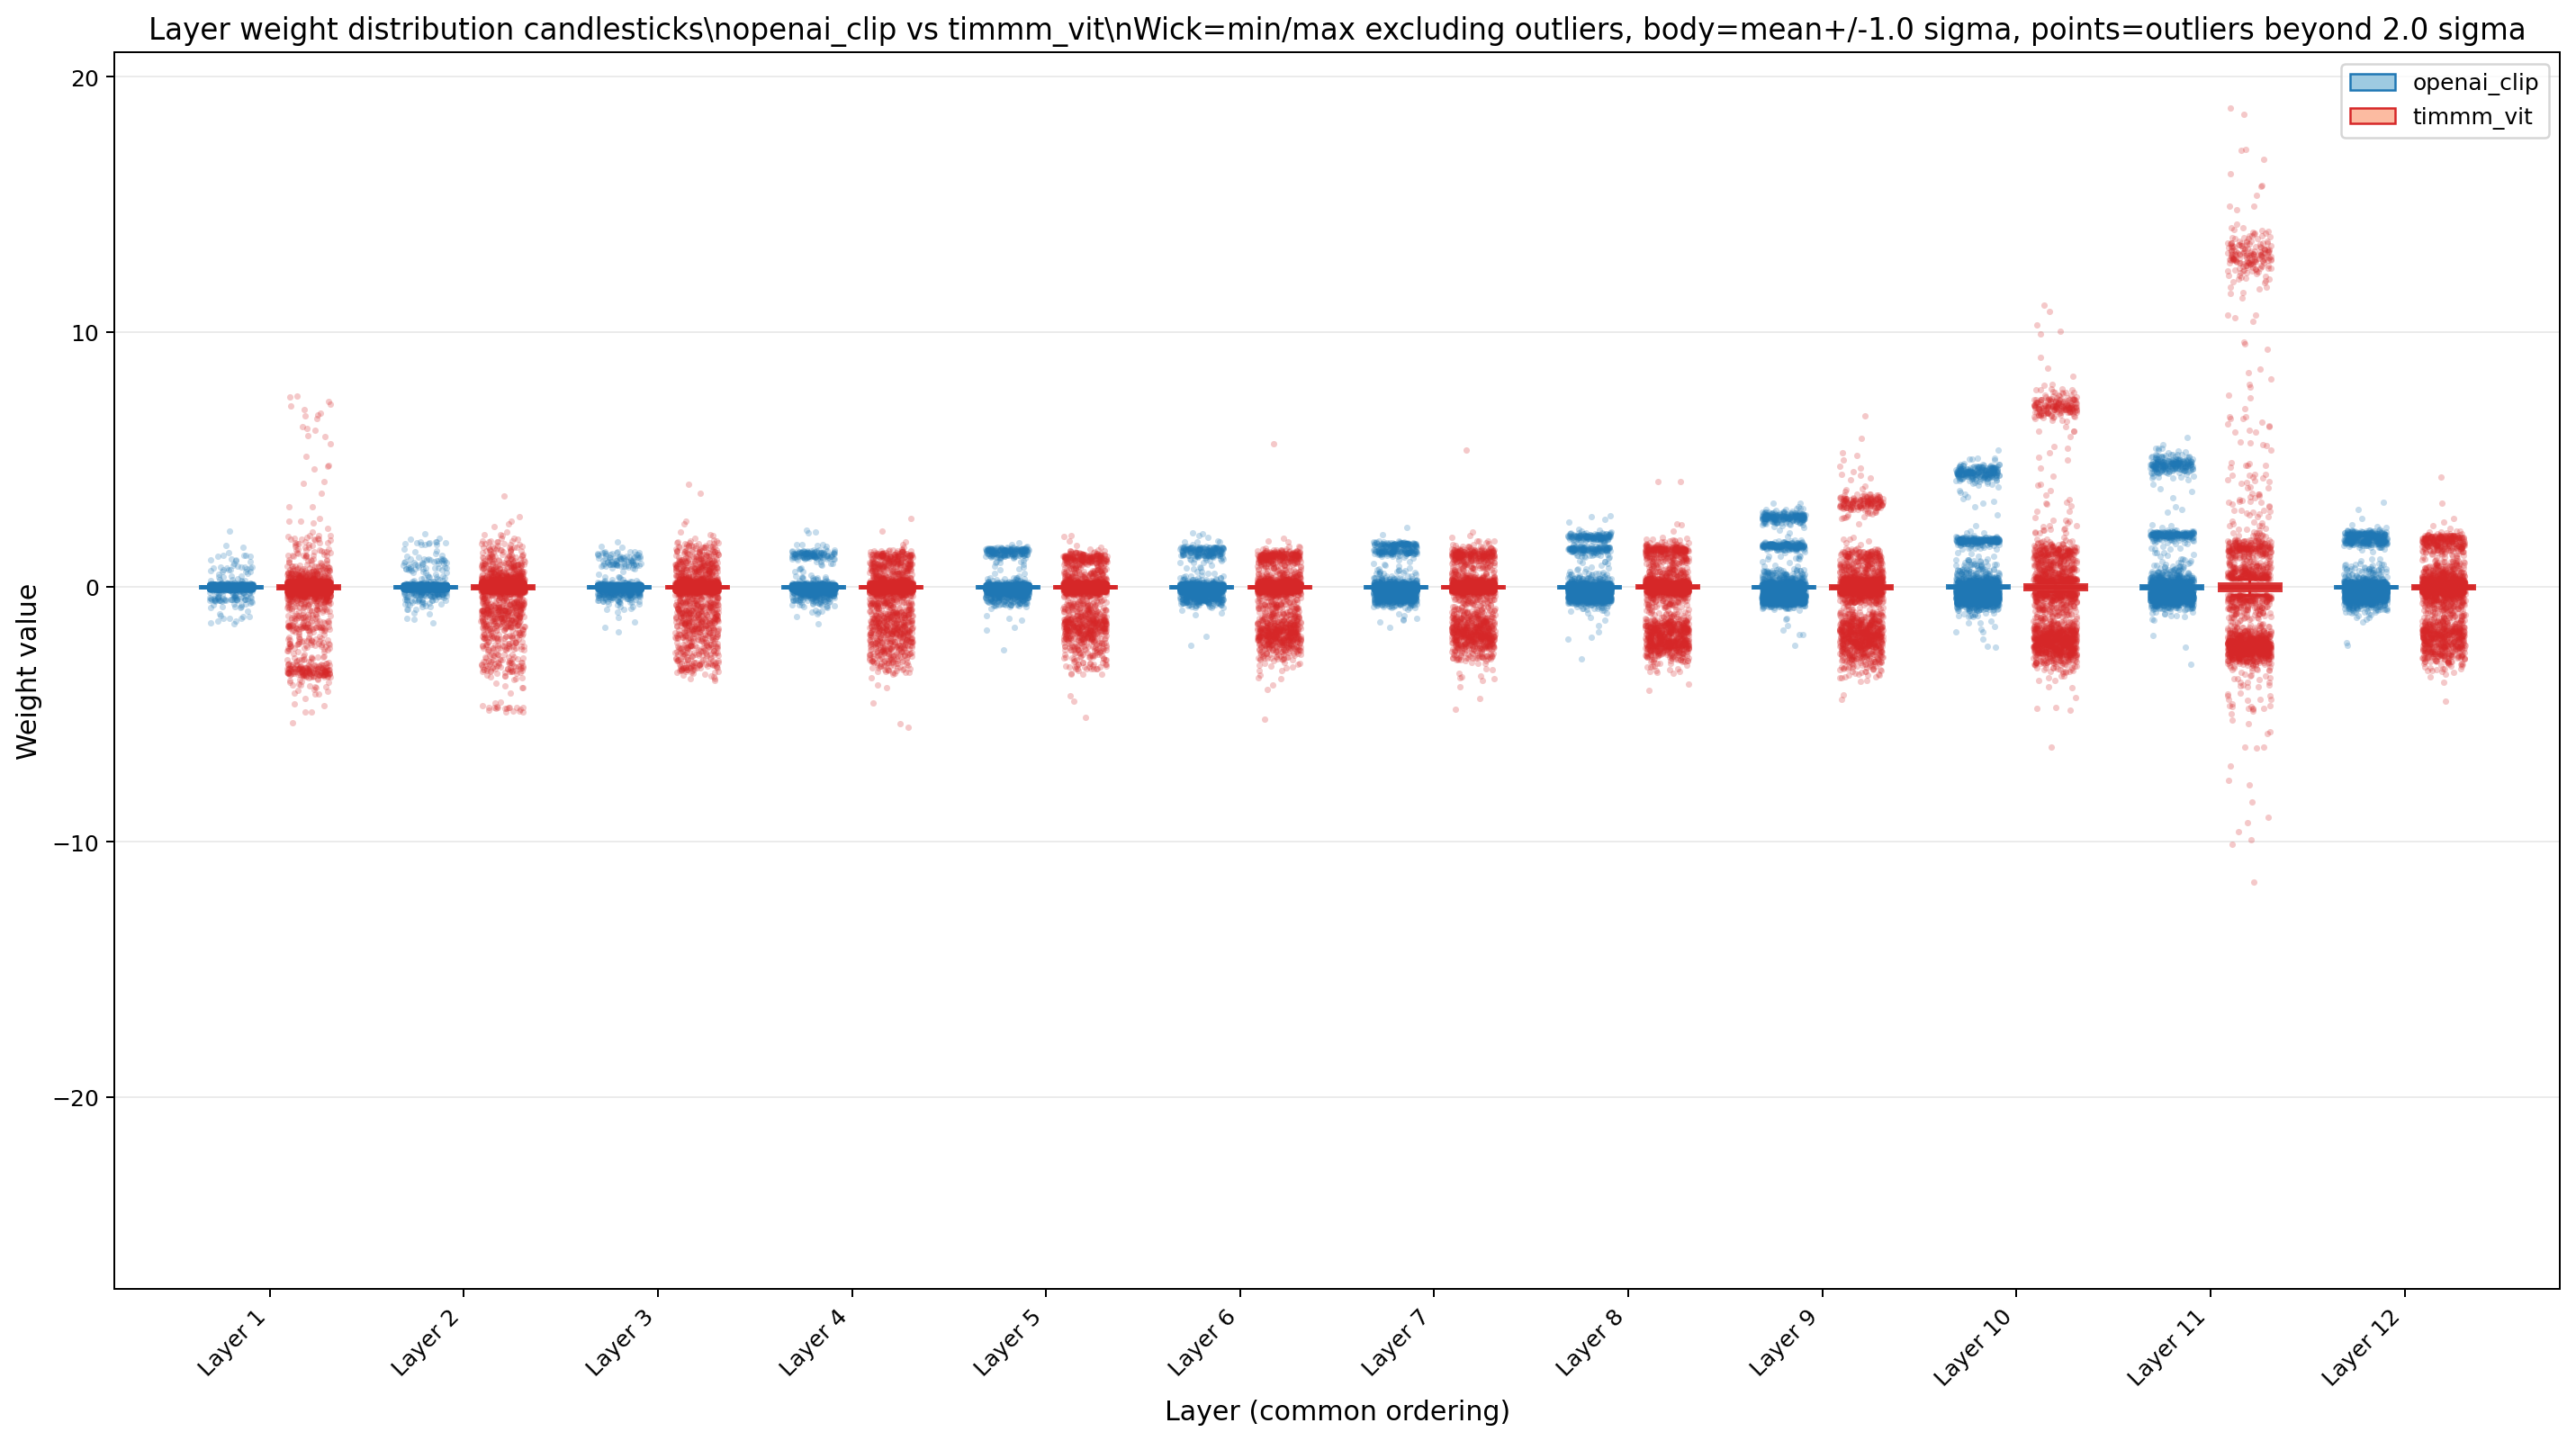

In [ ]:
plot_weight_candlesticks(
    stats_a=layer_stats_a,
    stats_b=layer_stats_b,
    model_a_name=MODEL_A_LABEL,
    model_b_name=MODEL_B_LABEL,
    ordered_layer_indices=common_layer_indices,
)

## Granular comparison across all layers

This is the requested view:
for each layer index `x`, compare component-by-component (`attention_x` vs `attention_x`, `mlp_x` vs `mlp_x`, etc.) through the last common layer.

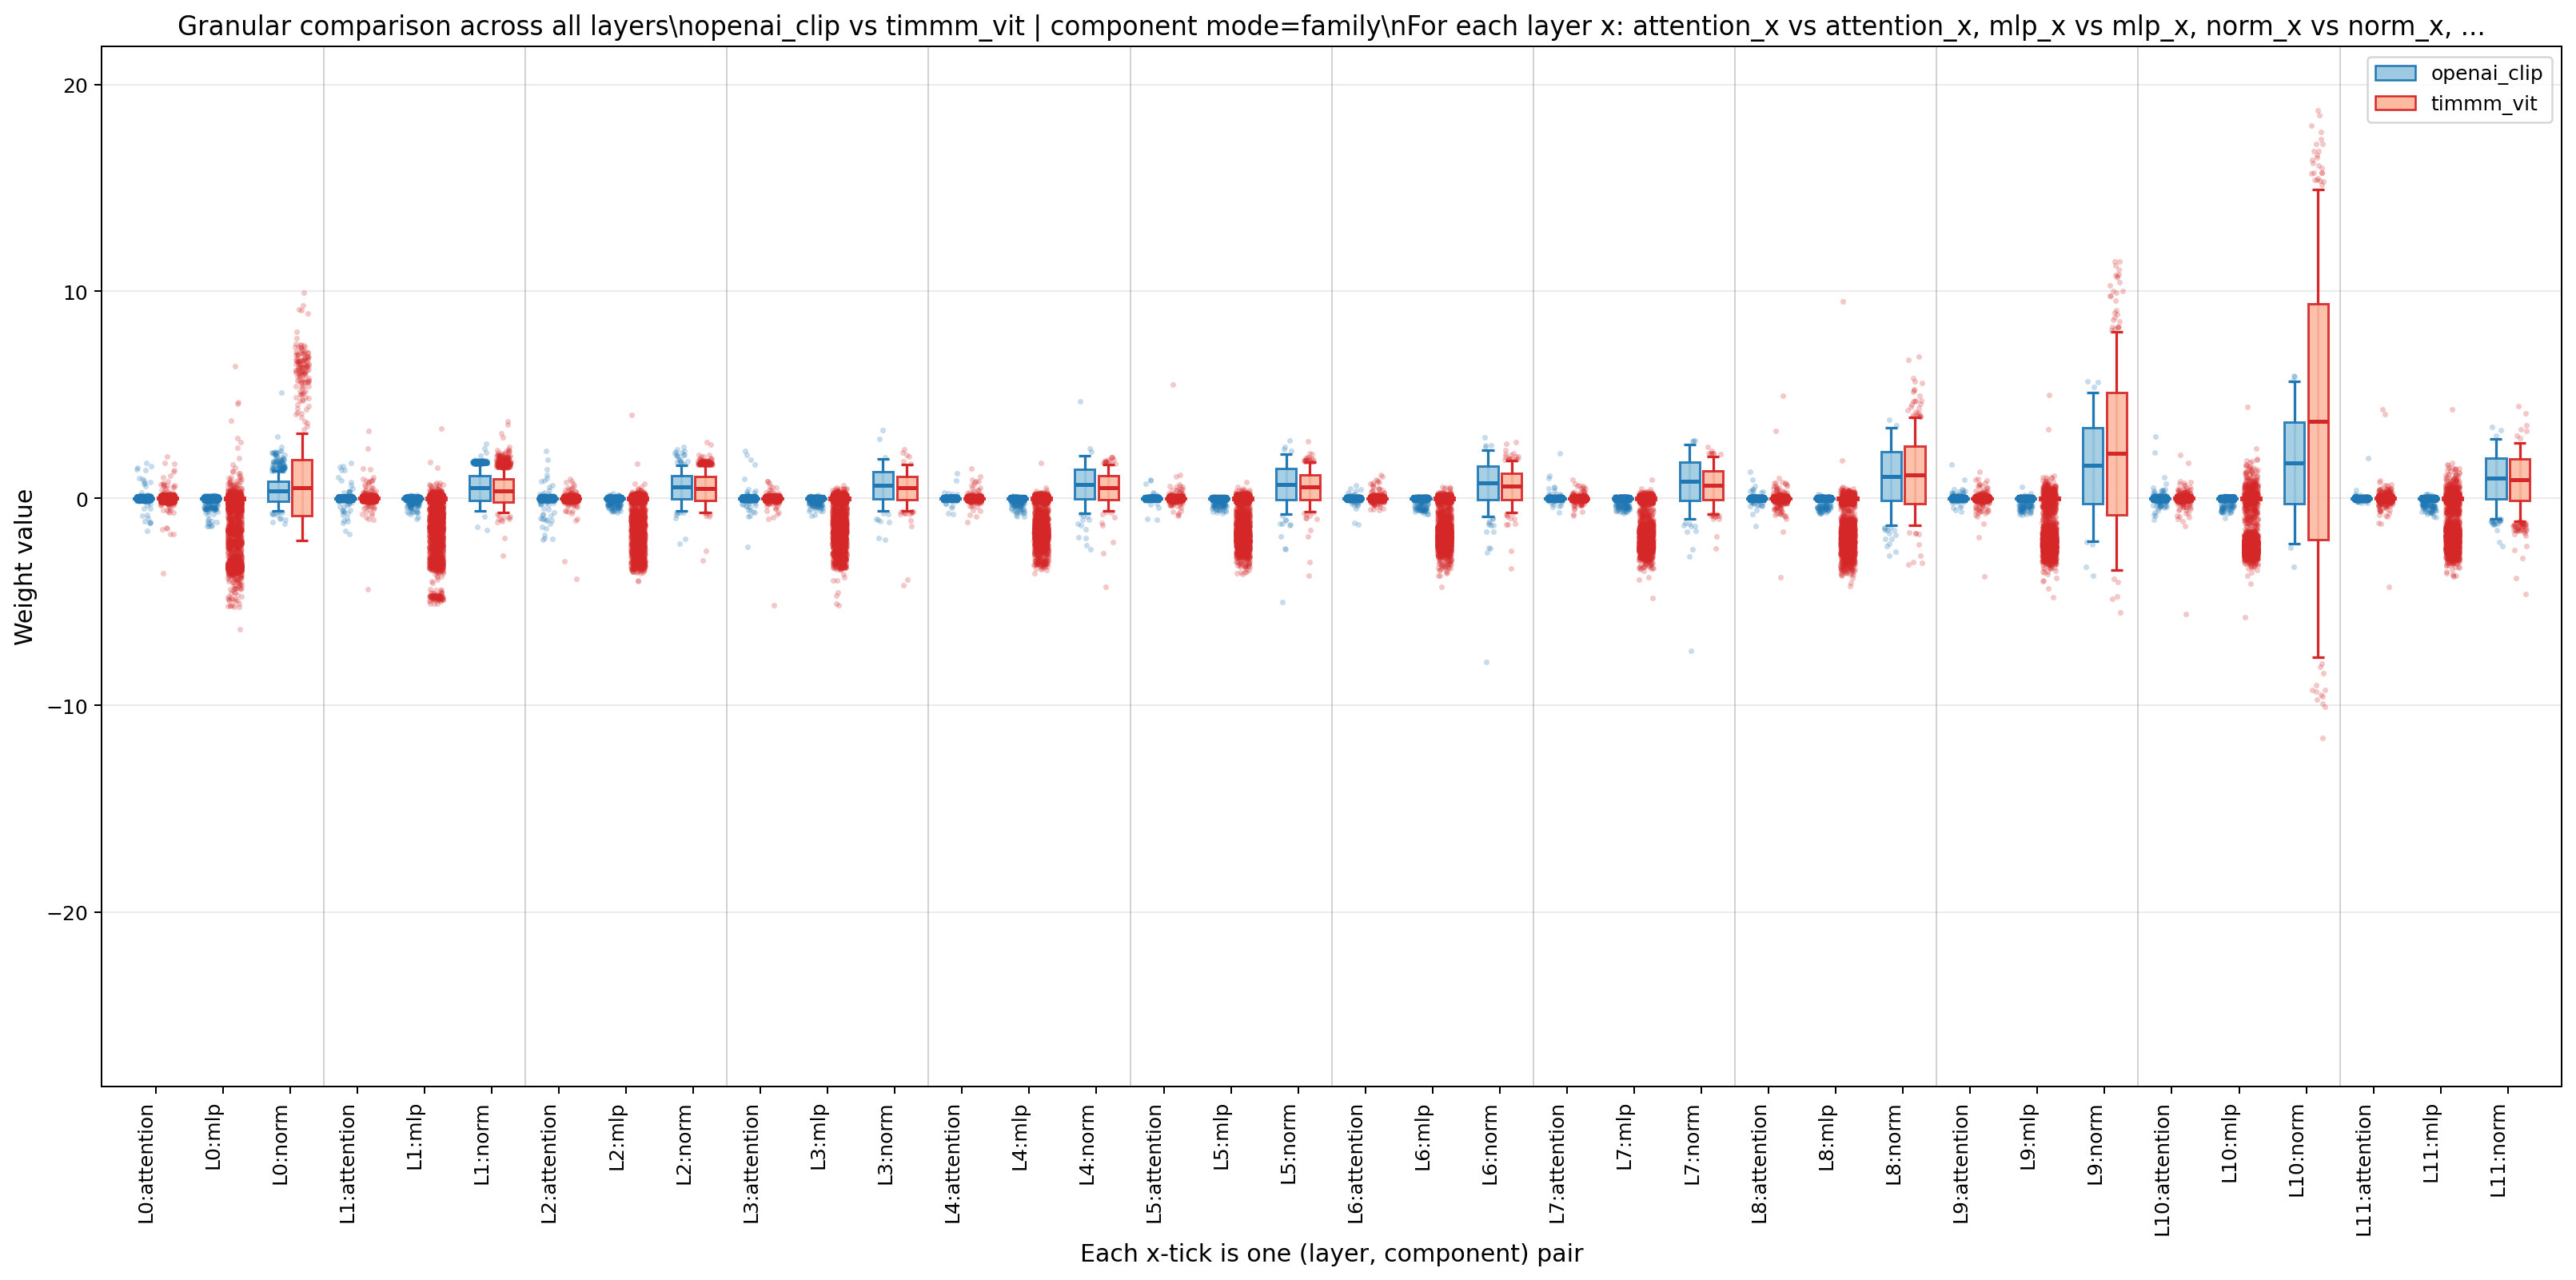

In [ ]:
plot_component_candlesticks_across_layers(
    component_stats_a=component_stats_a,
    component_stats_b=component_stats_b,
    model_a_name=MODEL_A_LABEL,
    model_b_name=MODEL_B_LABEL,
    ordered_layer_indices=common_layer_indices,
)

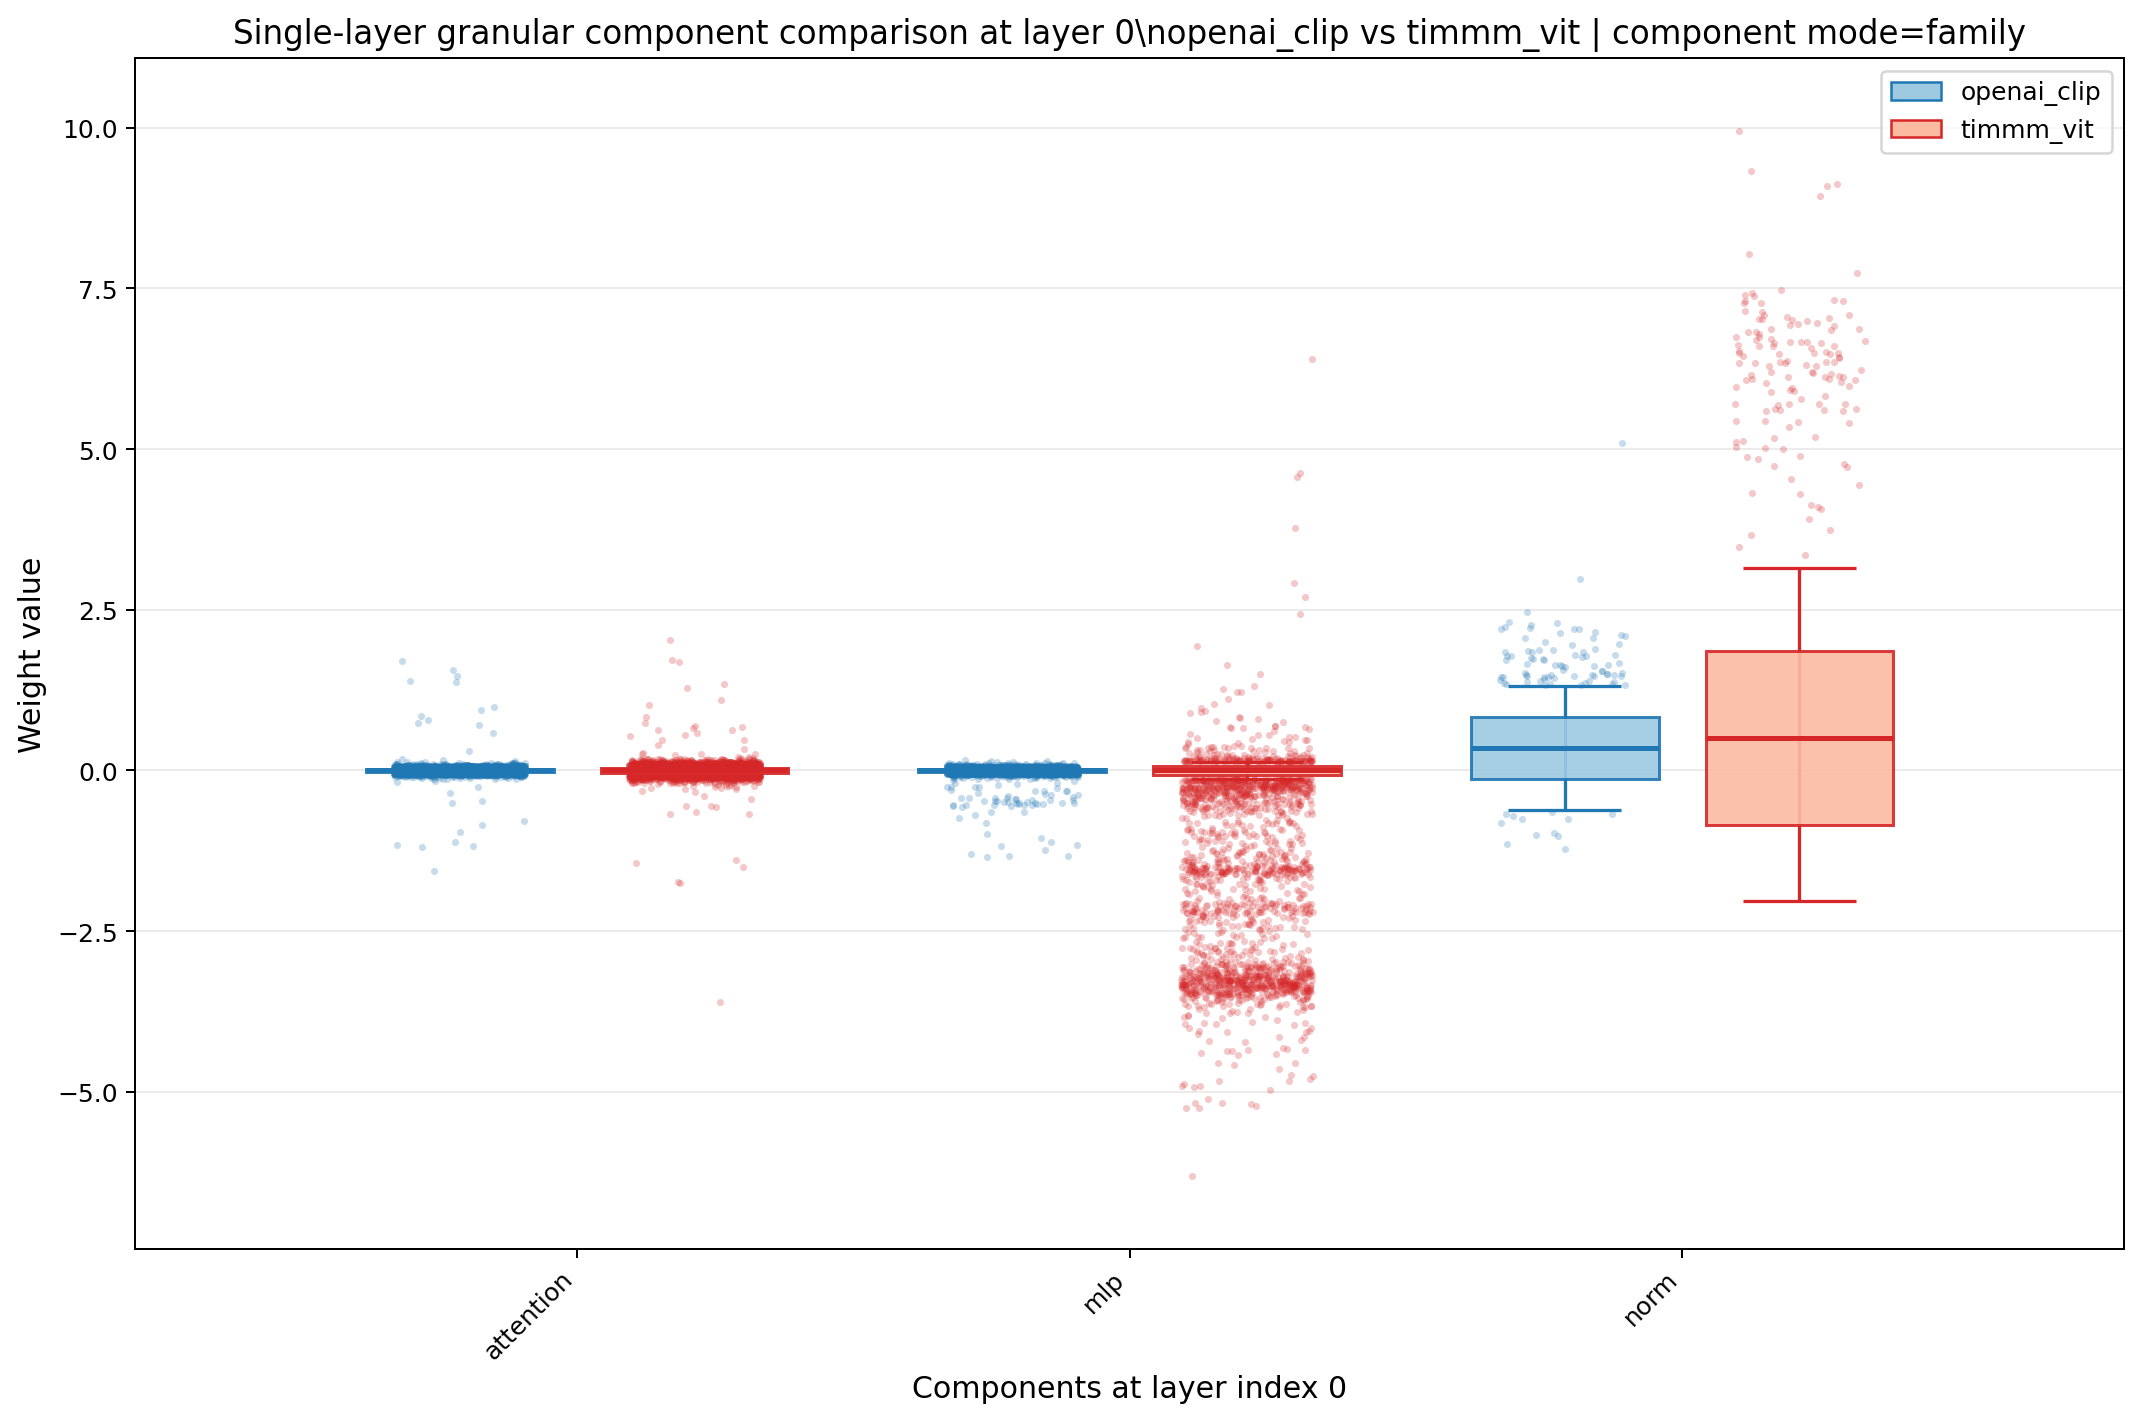

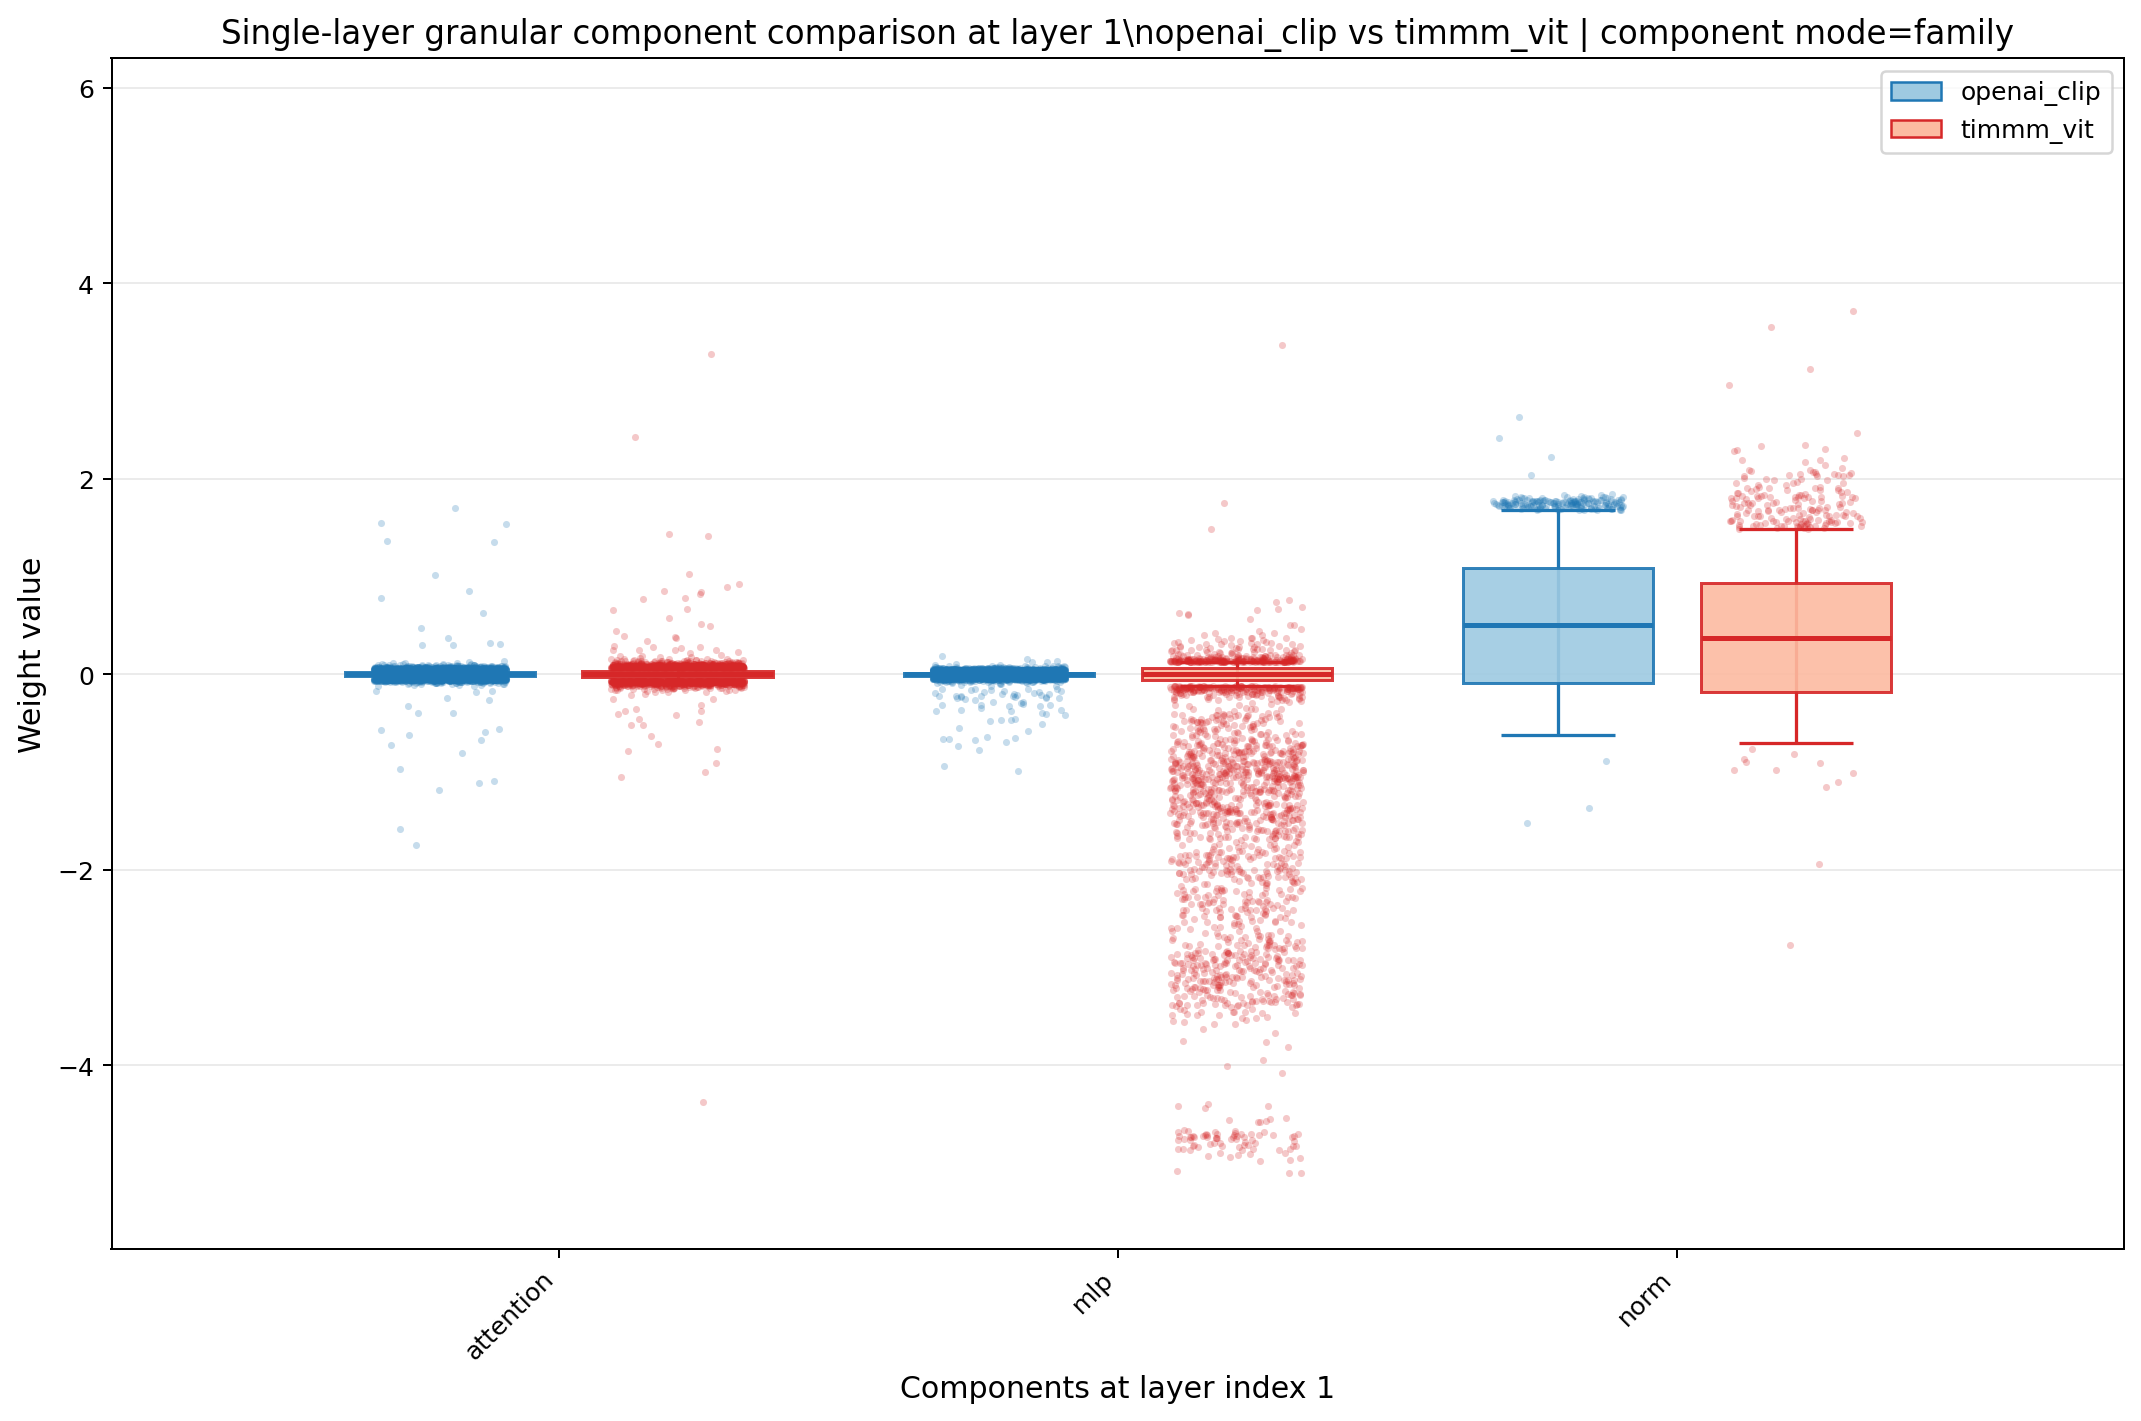

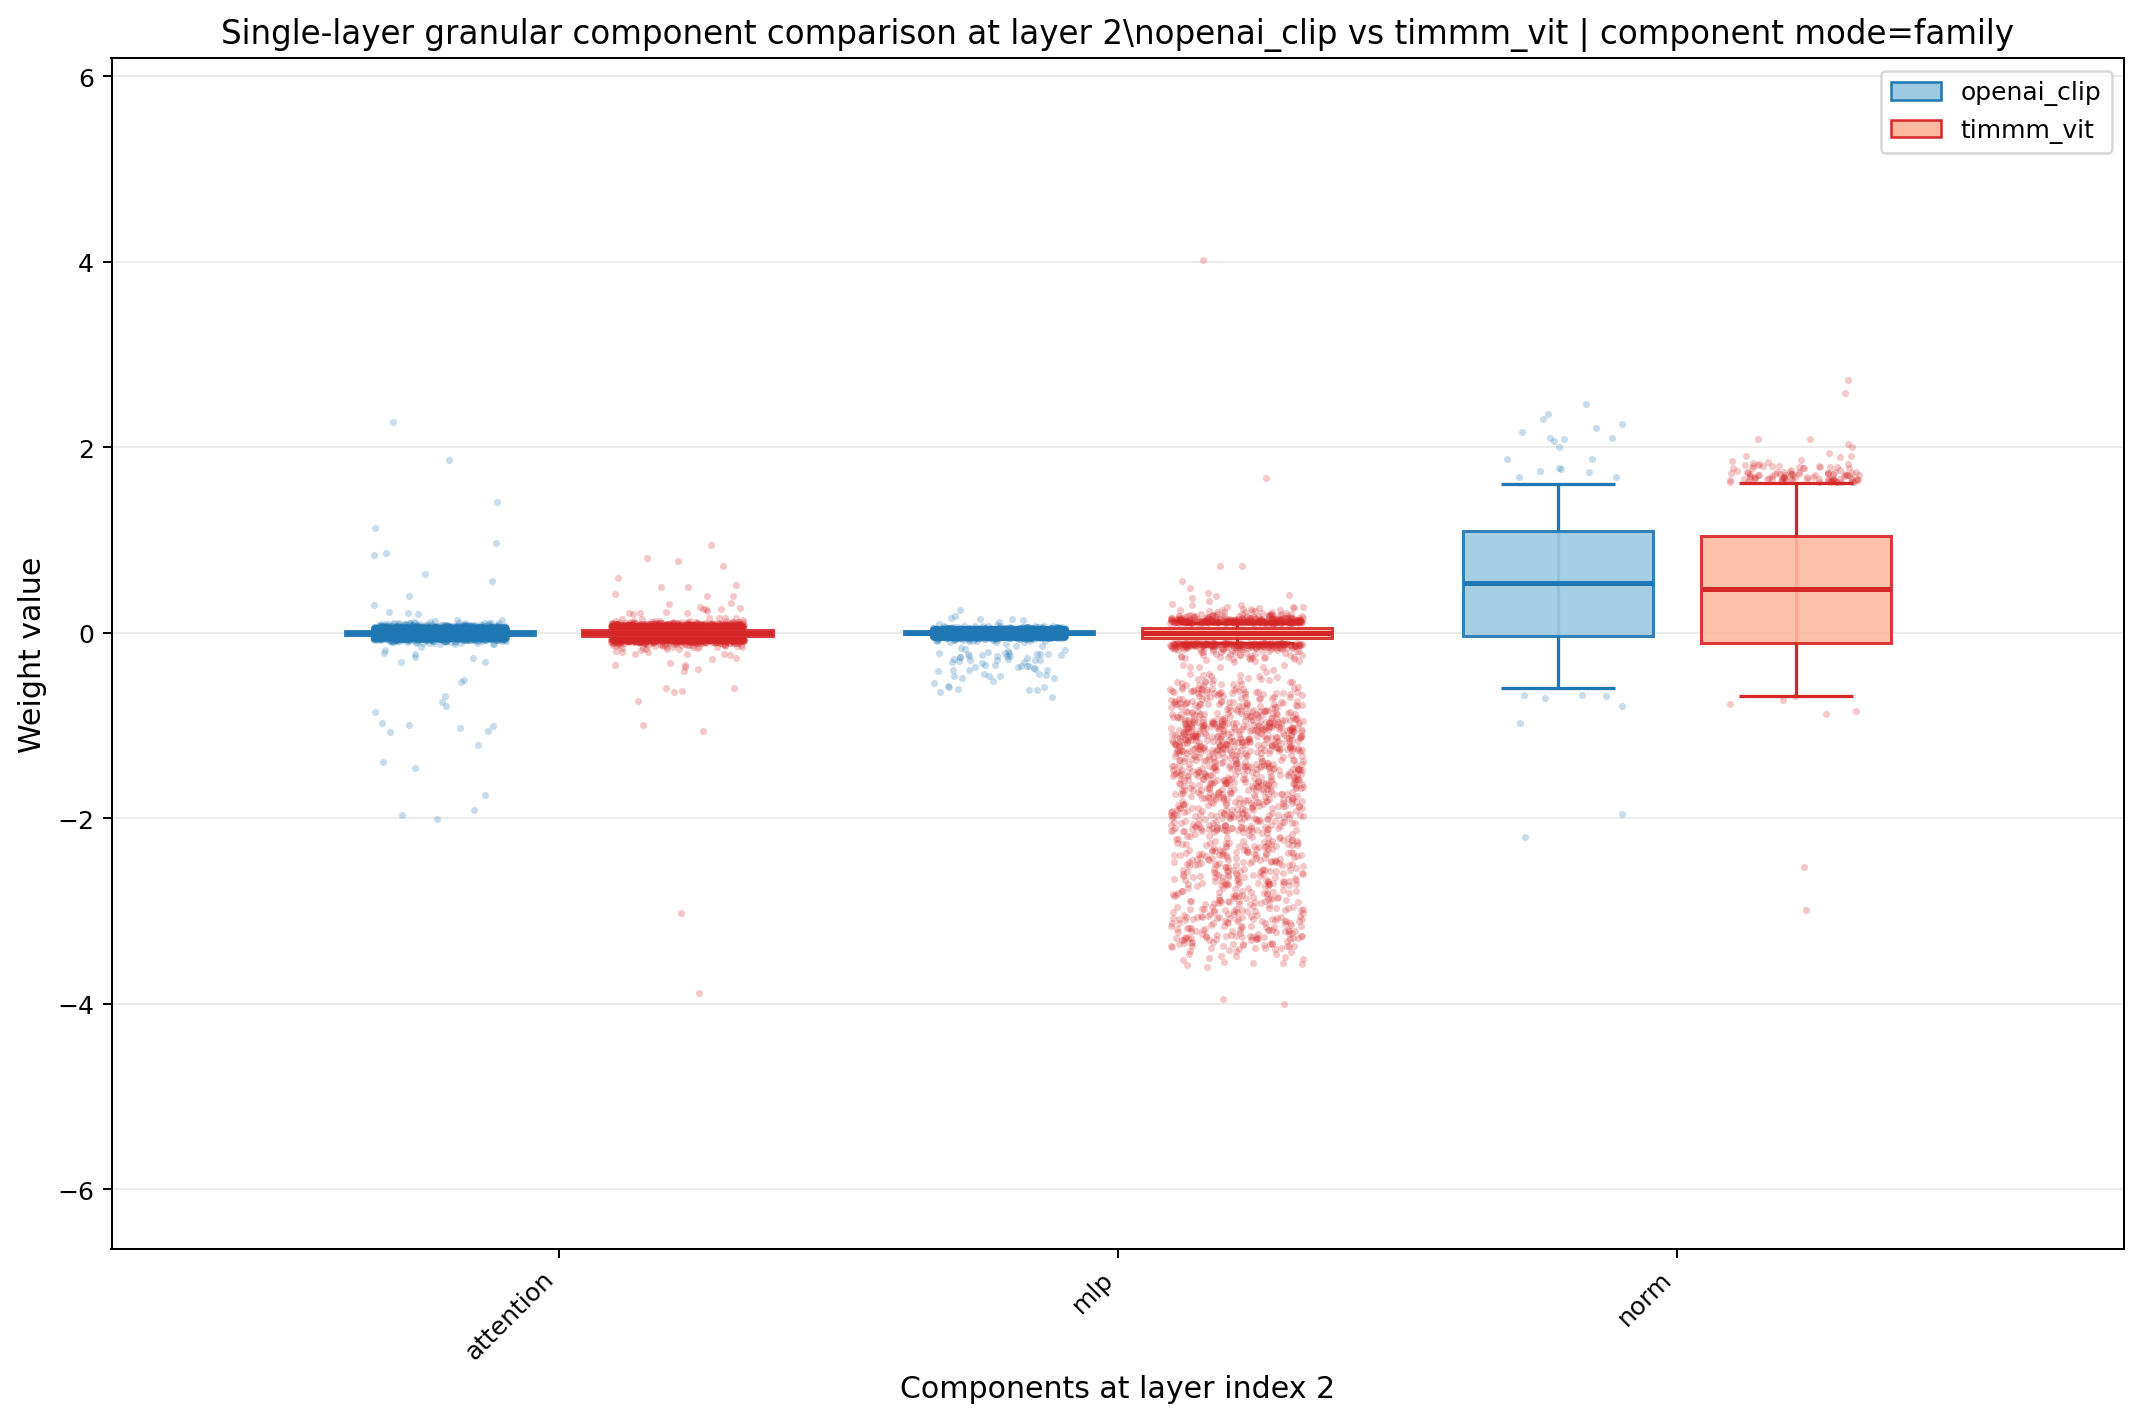

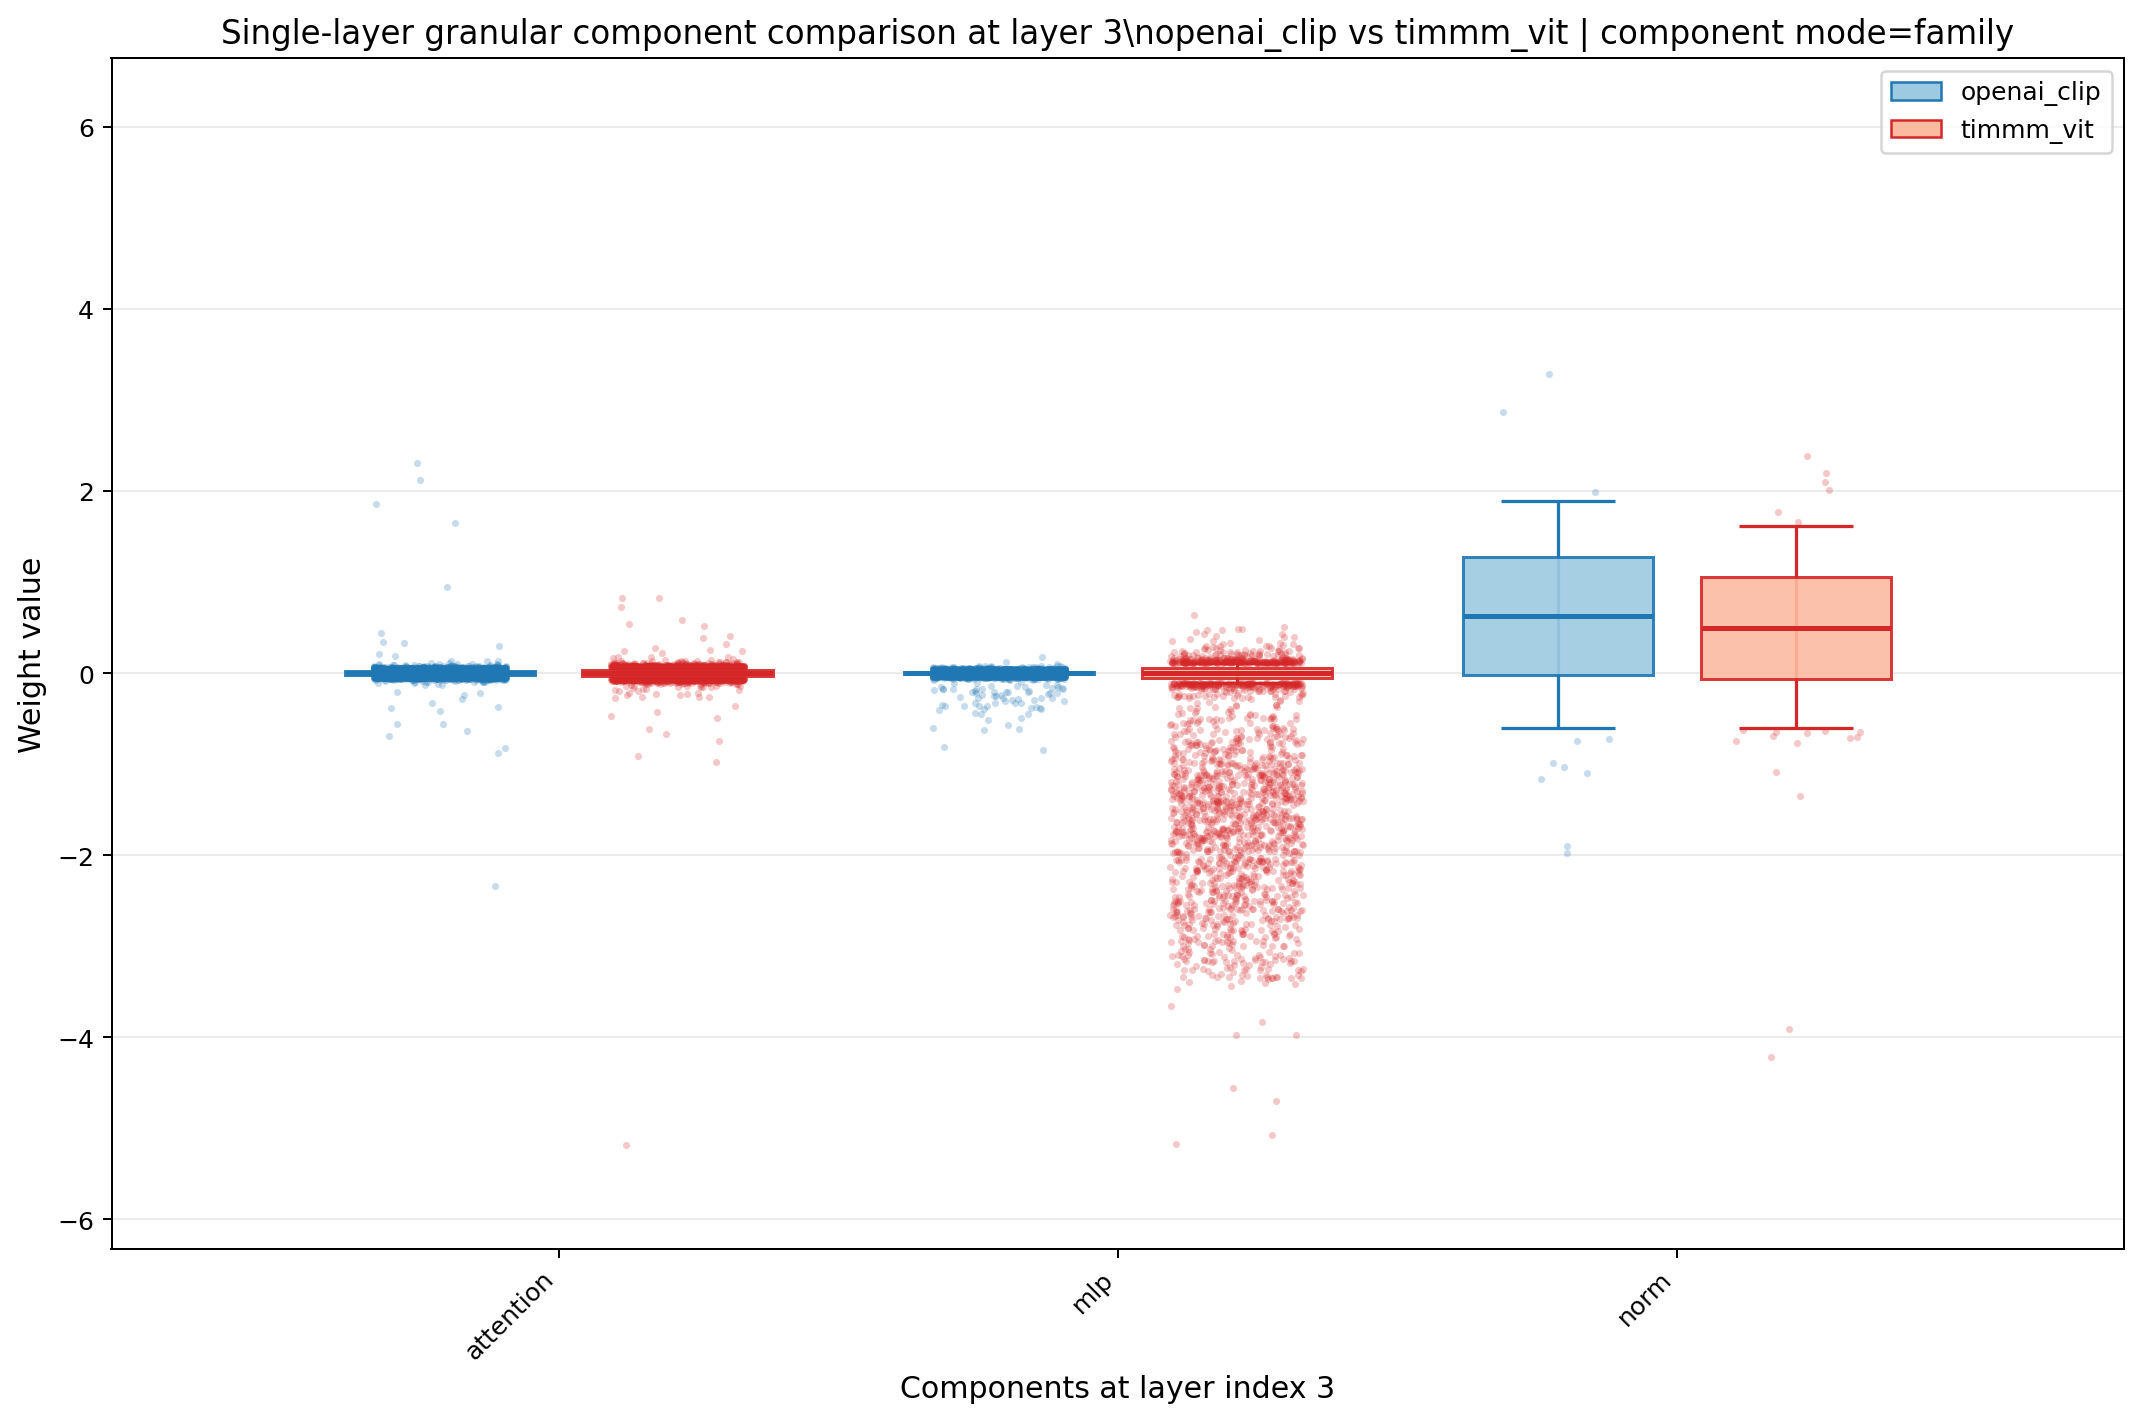

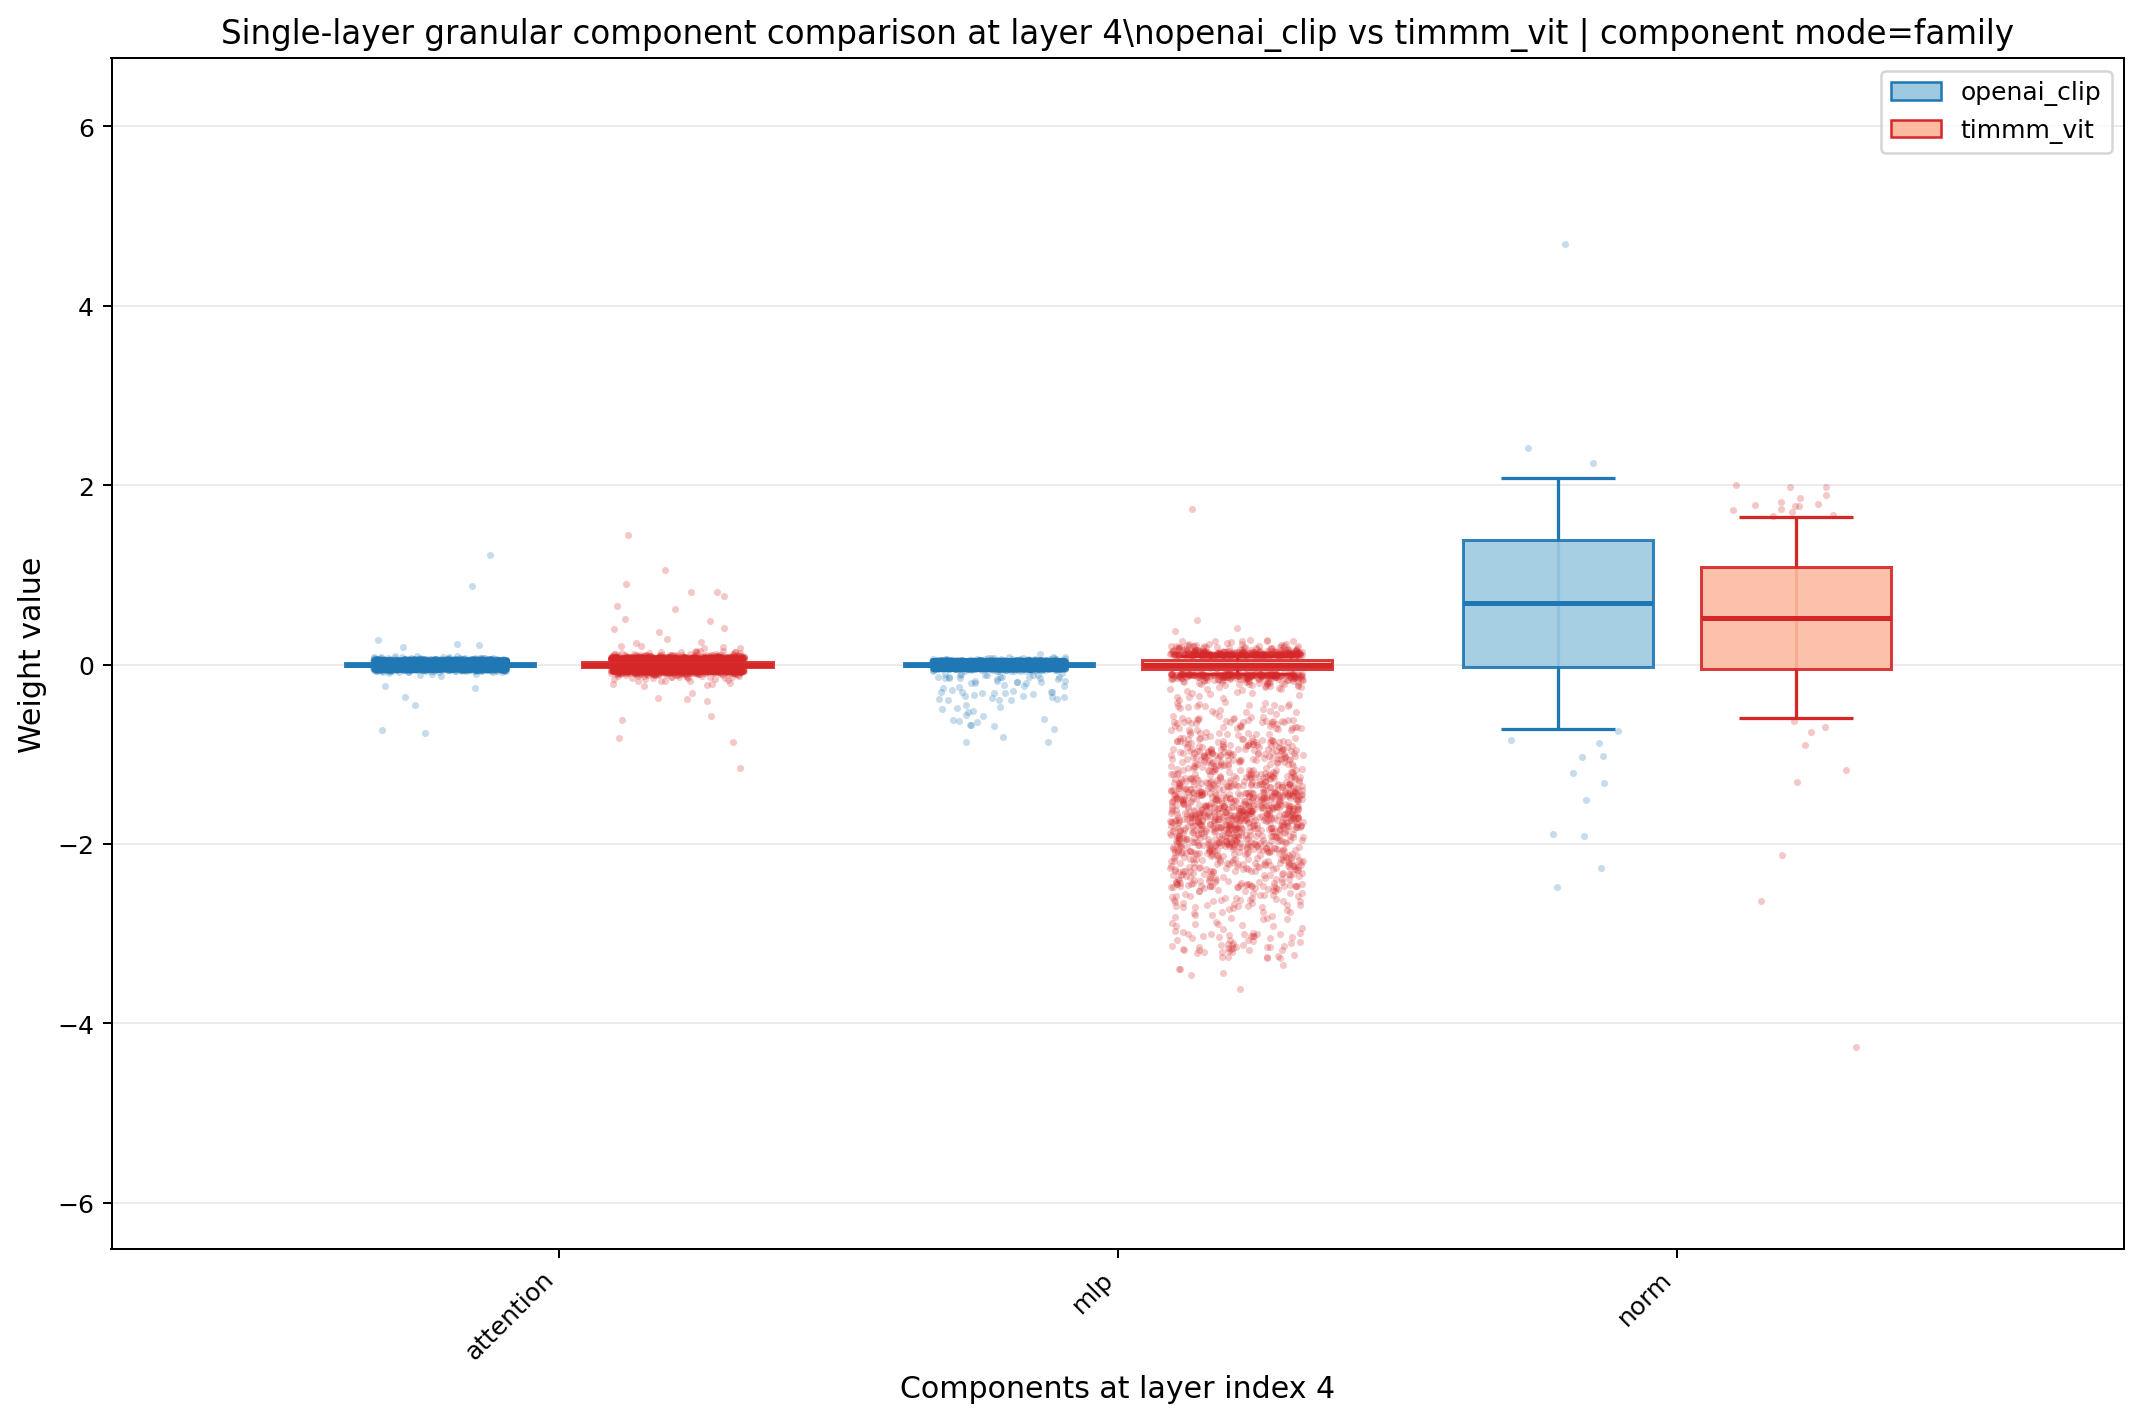

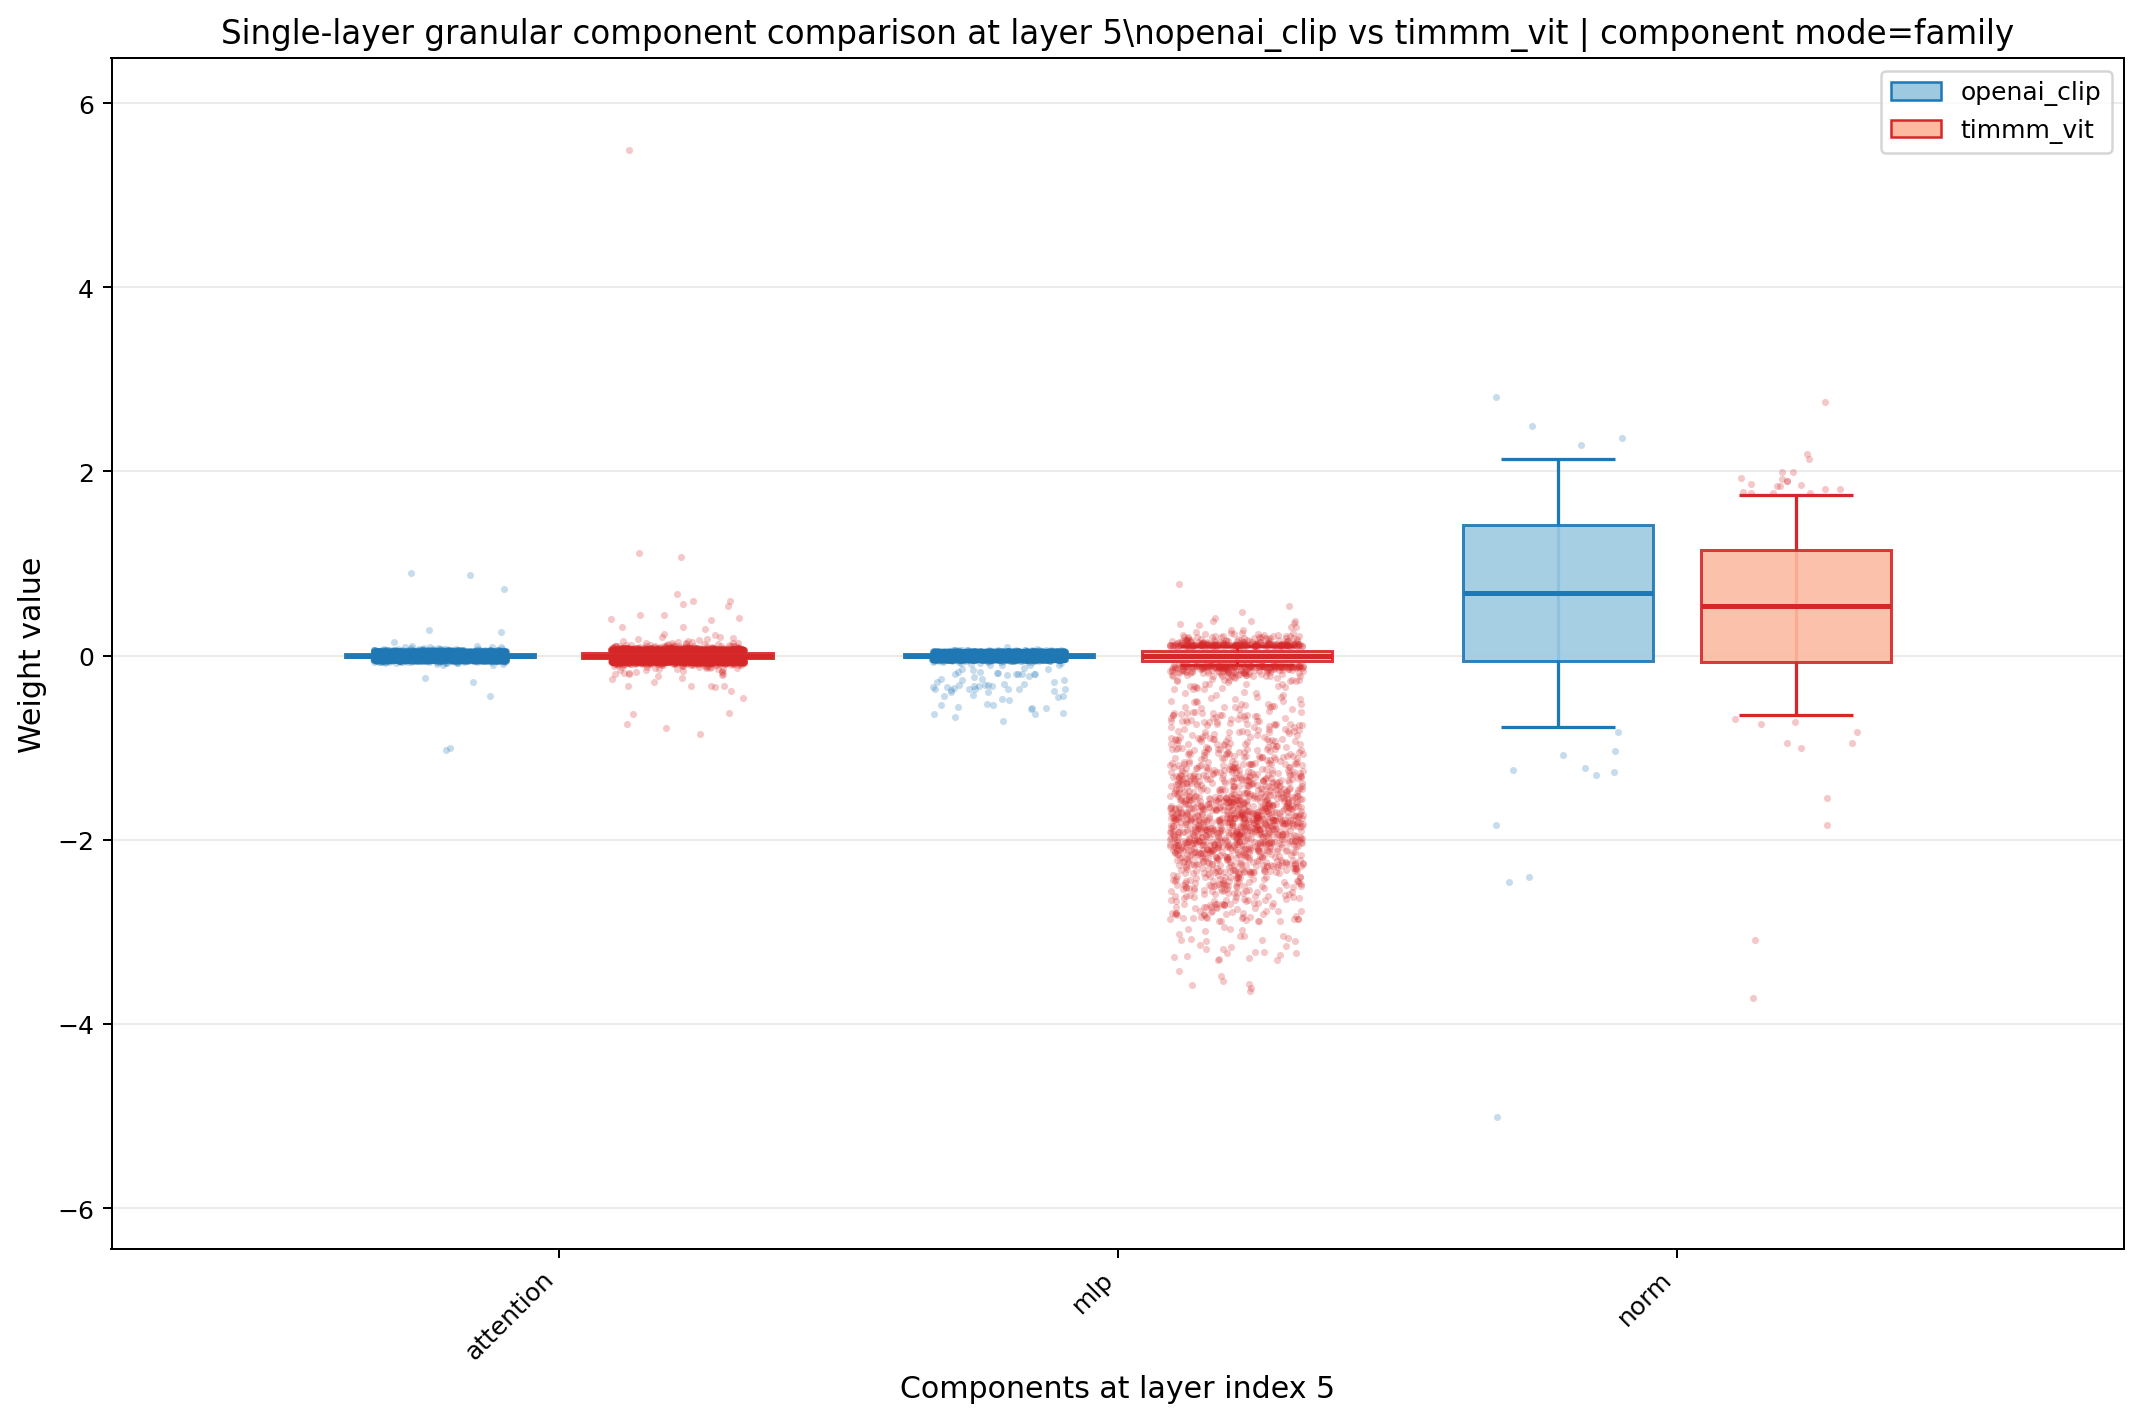

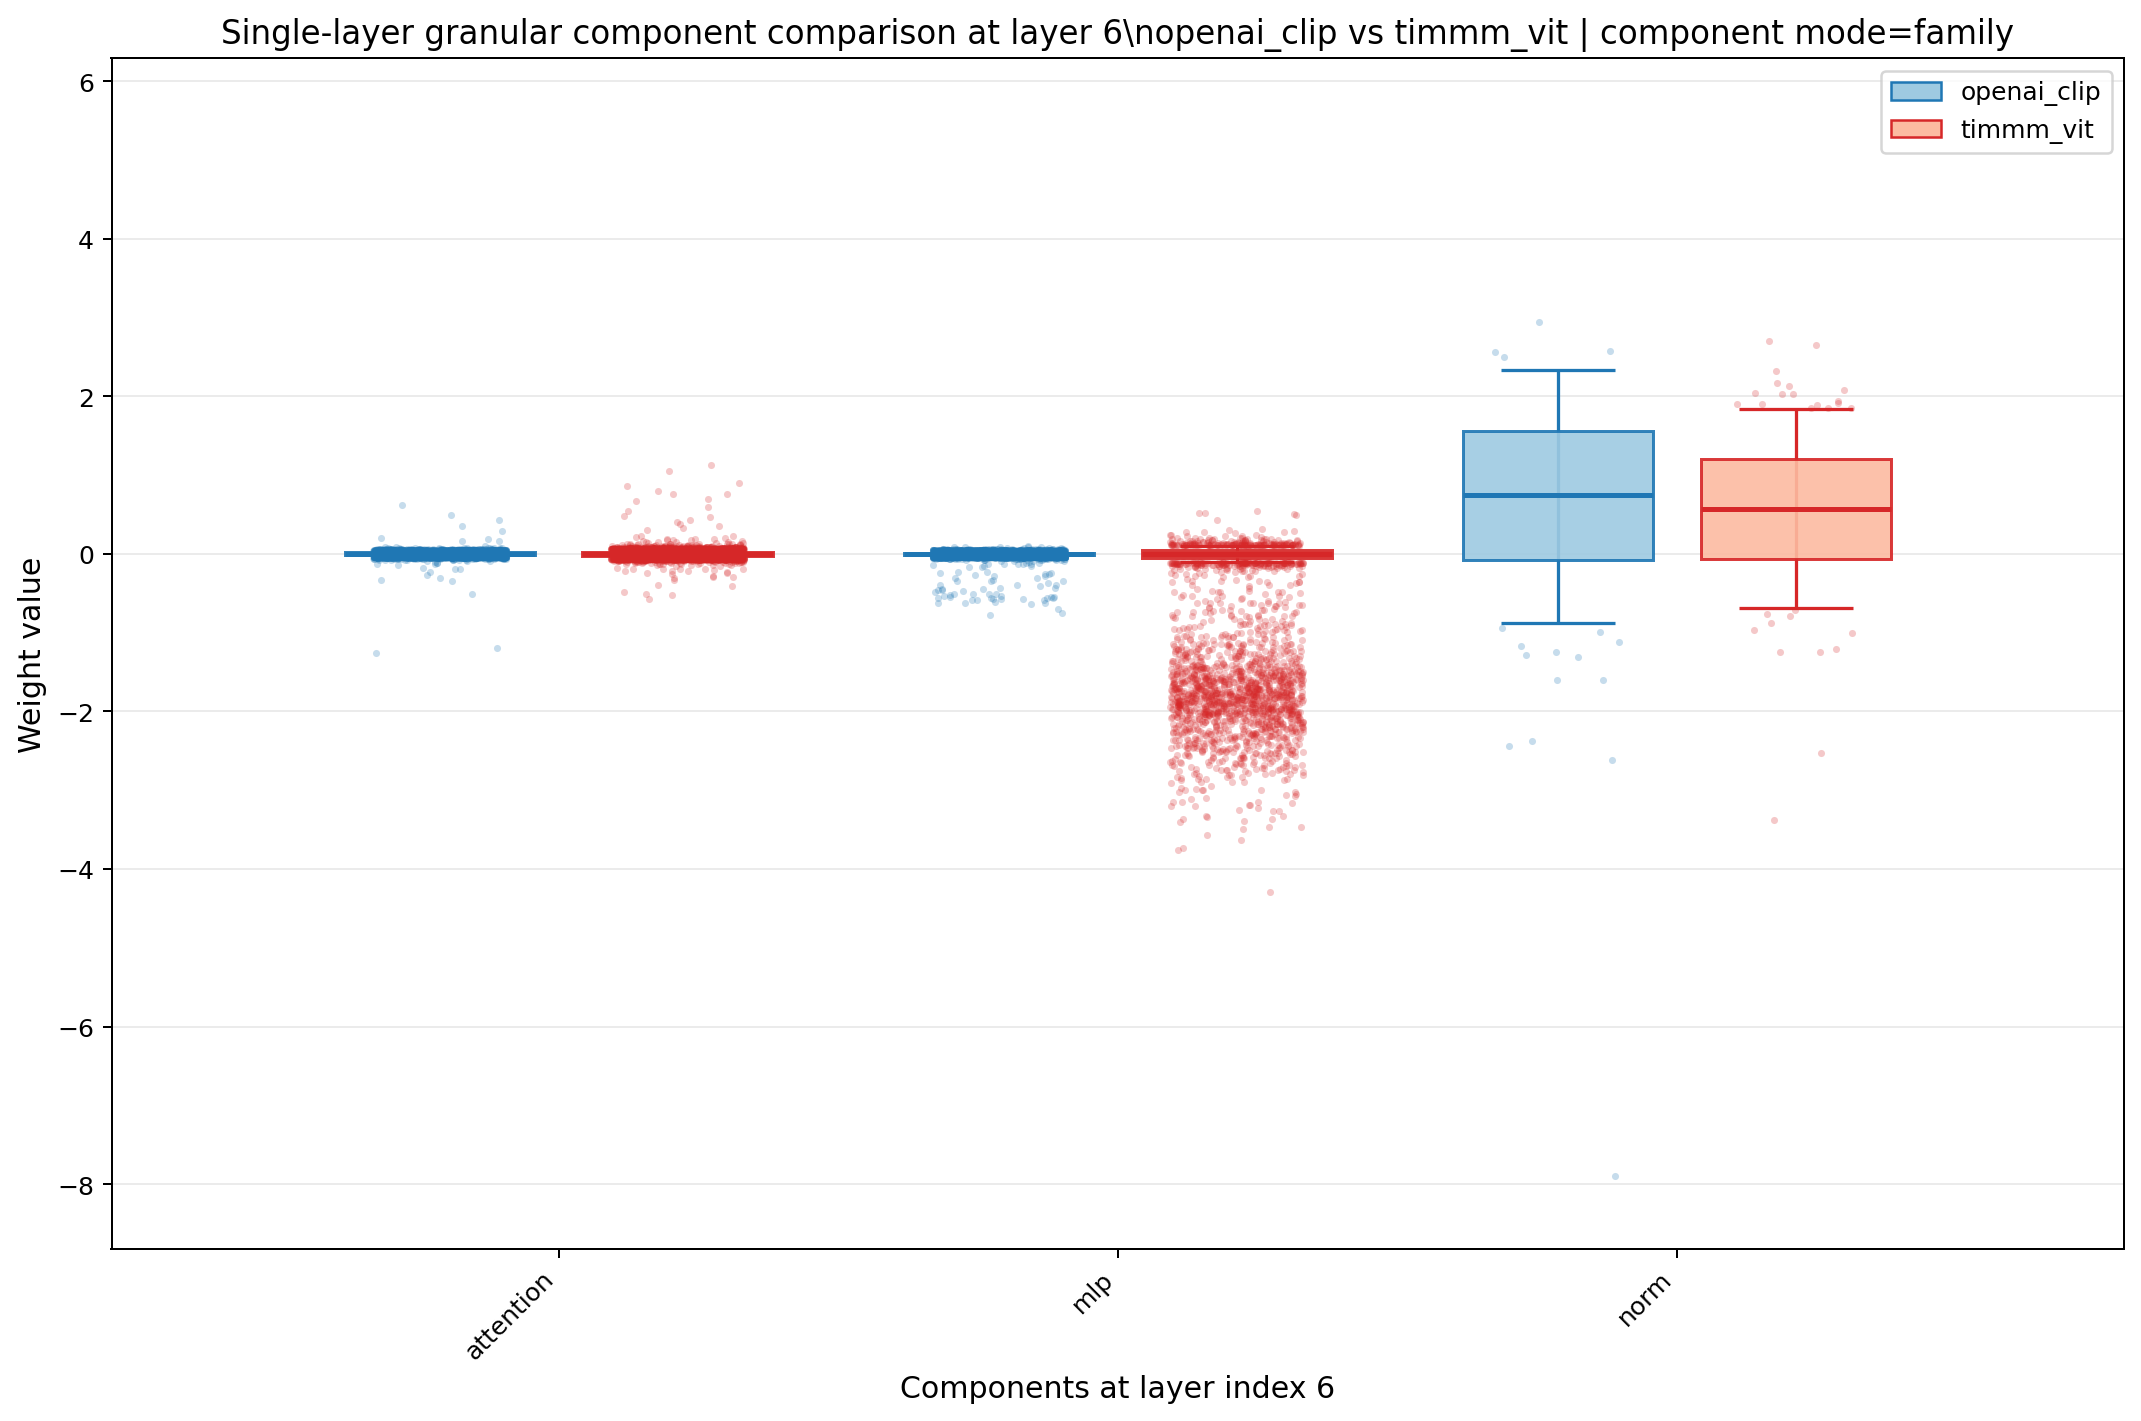

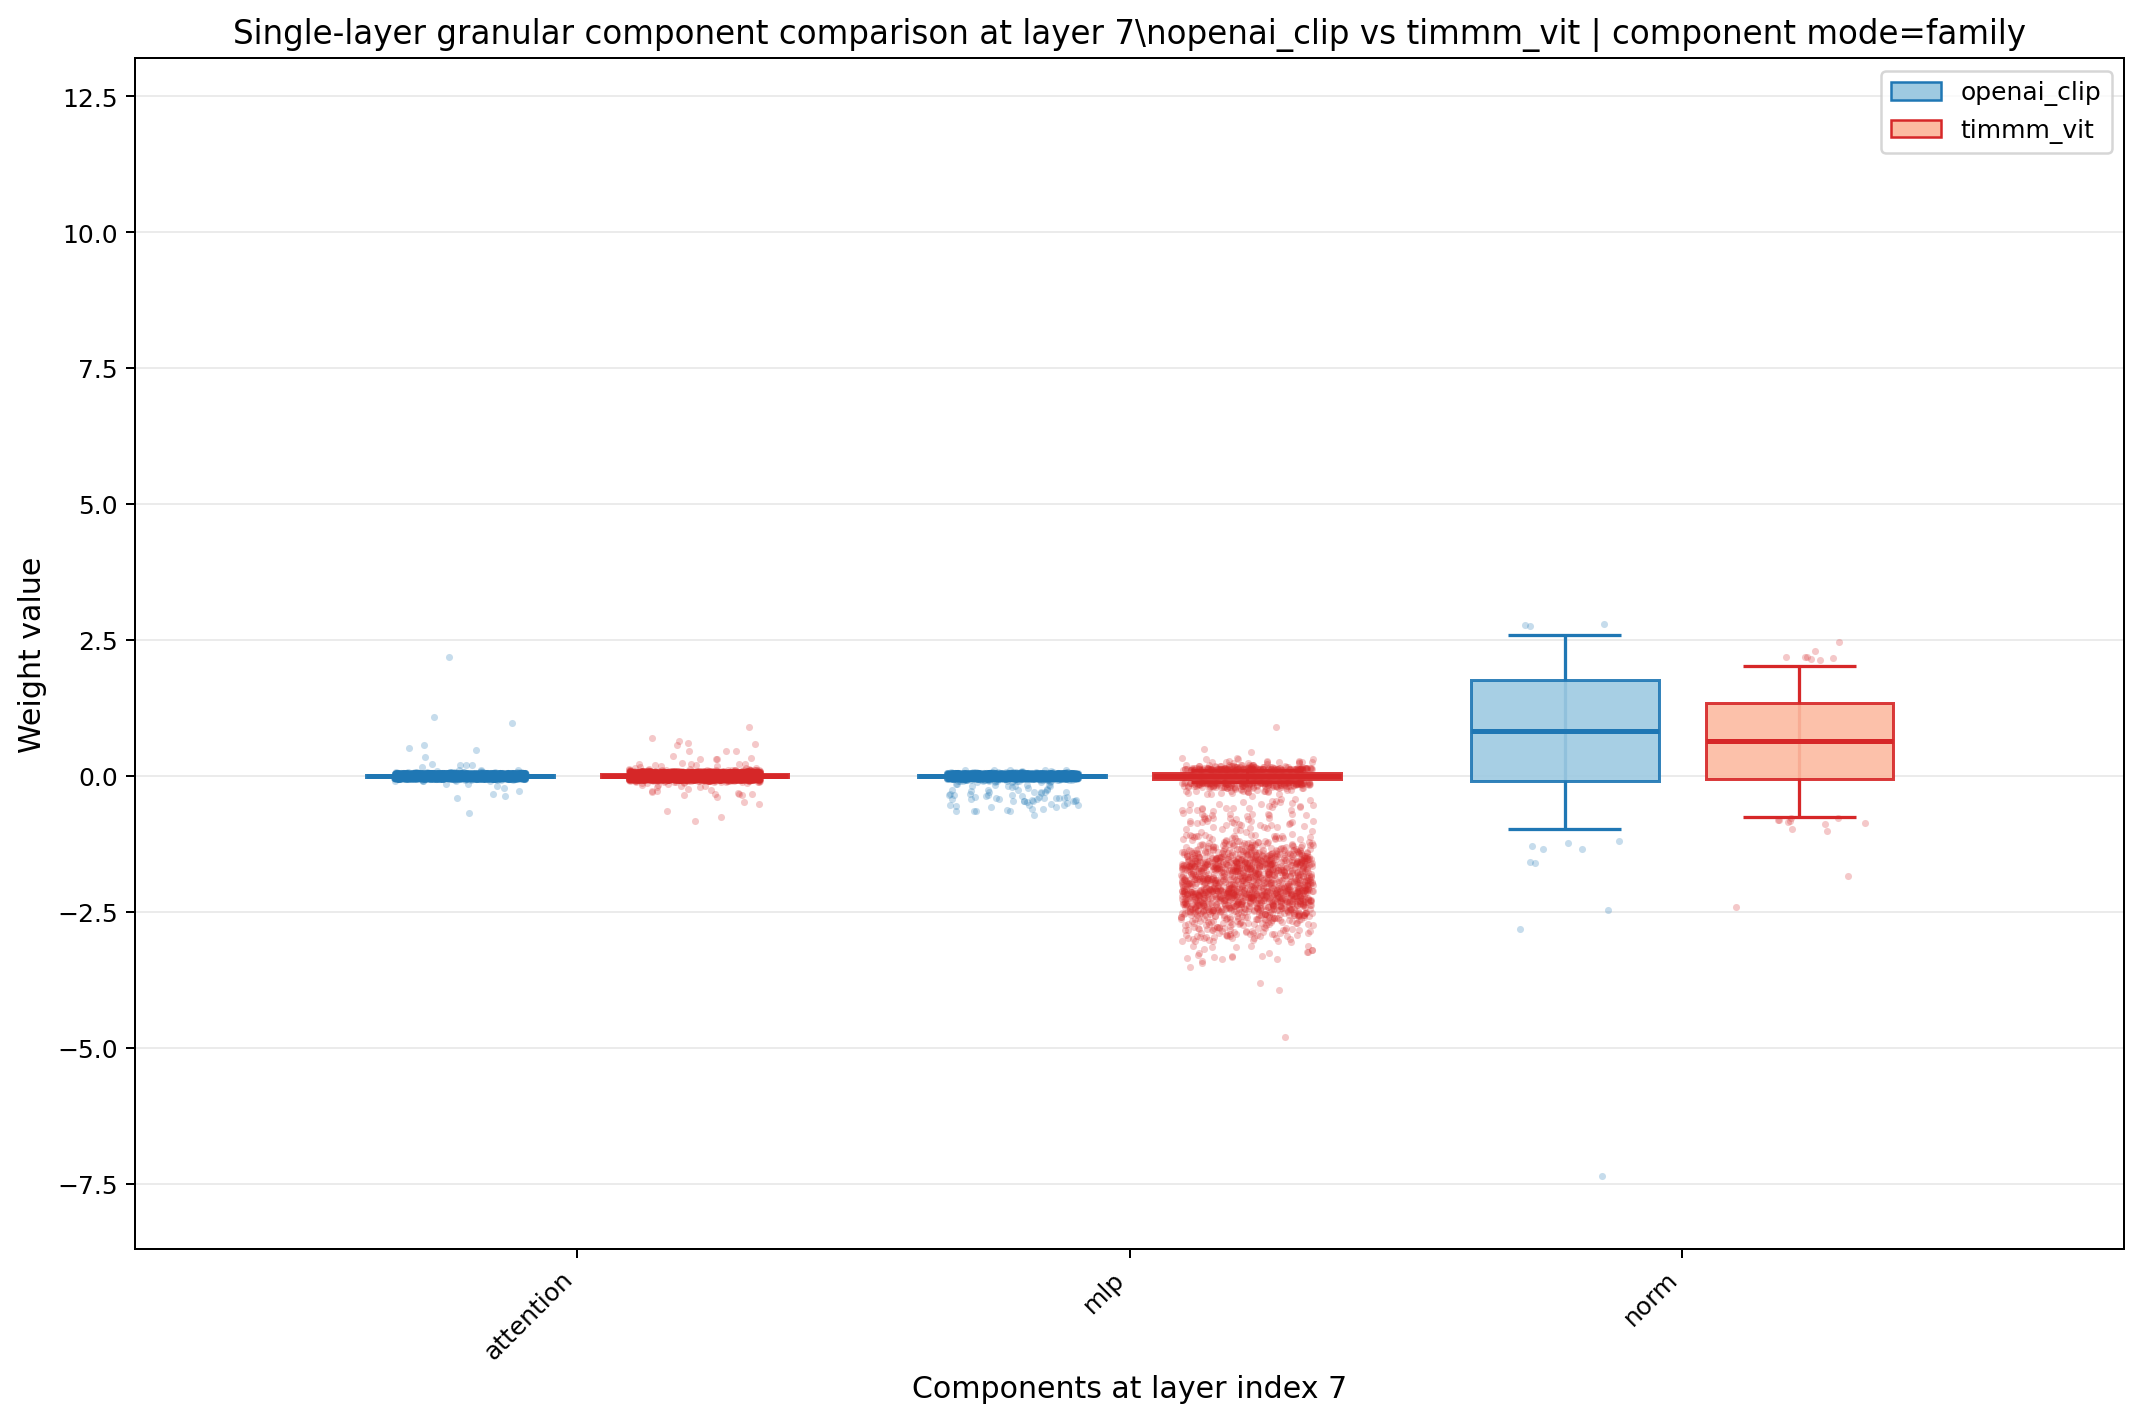

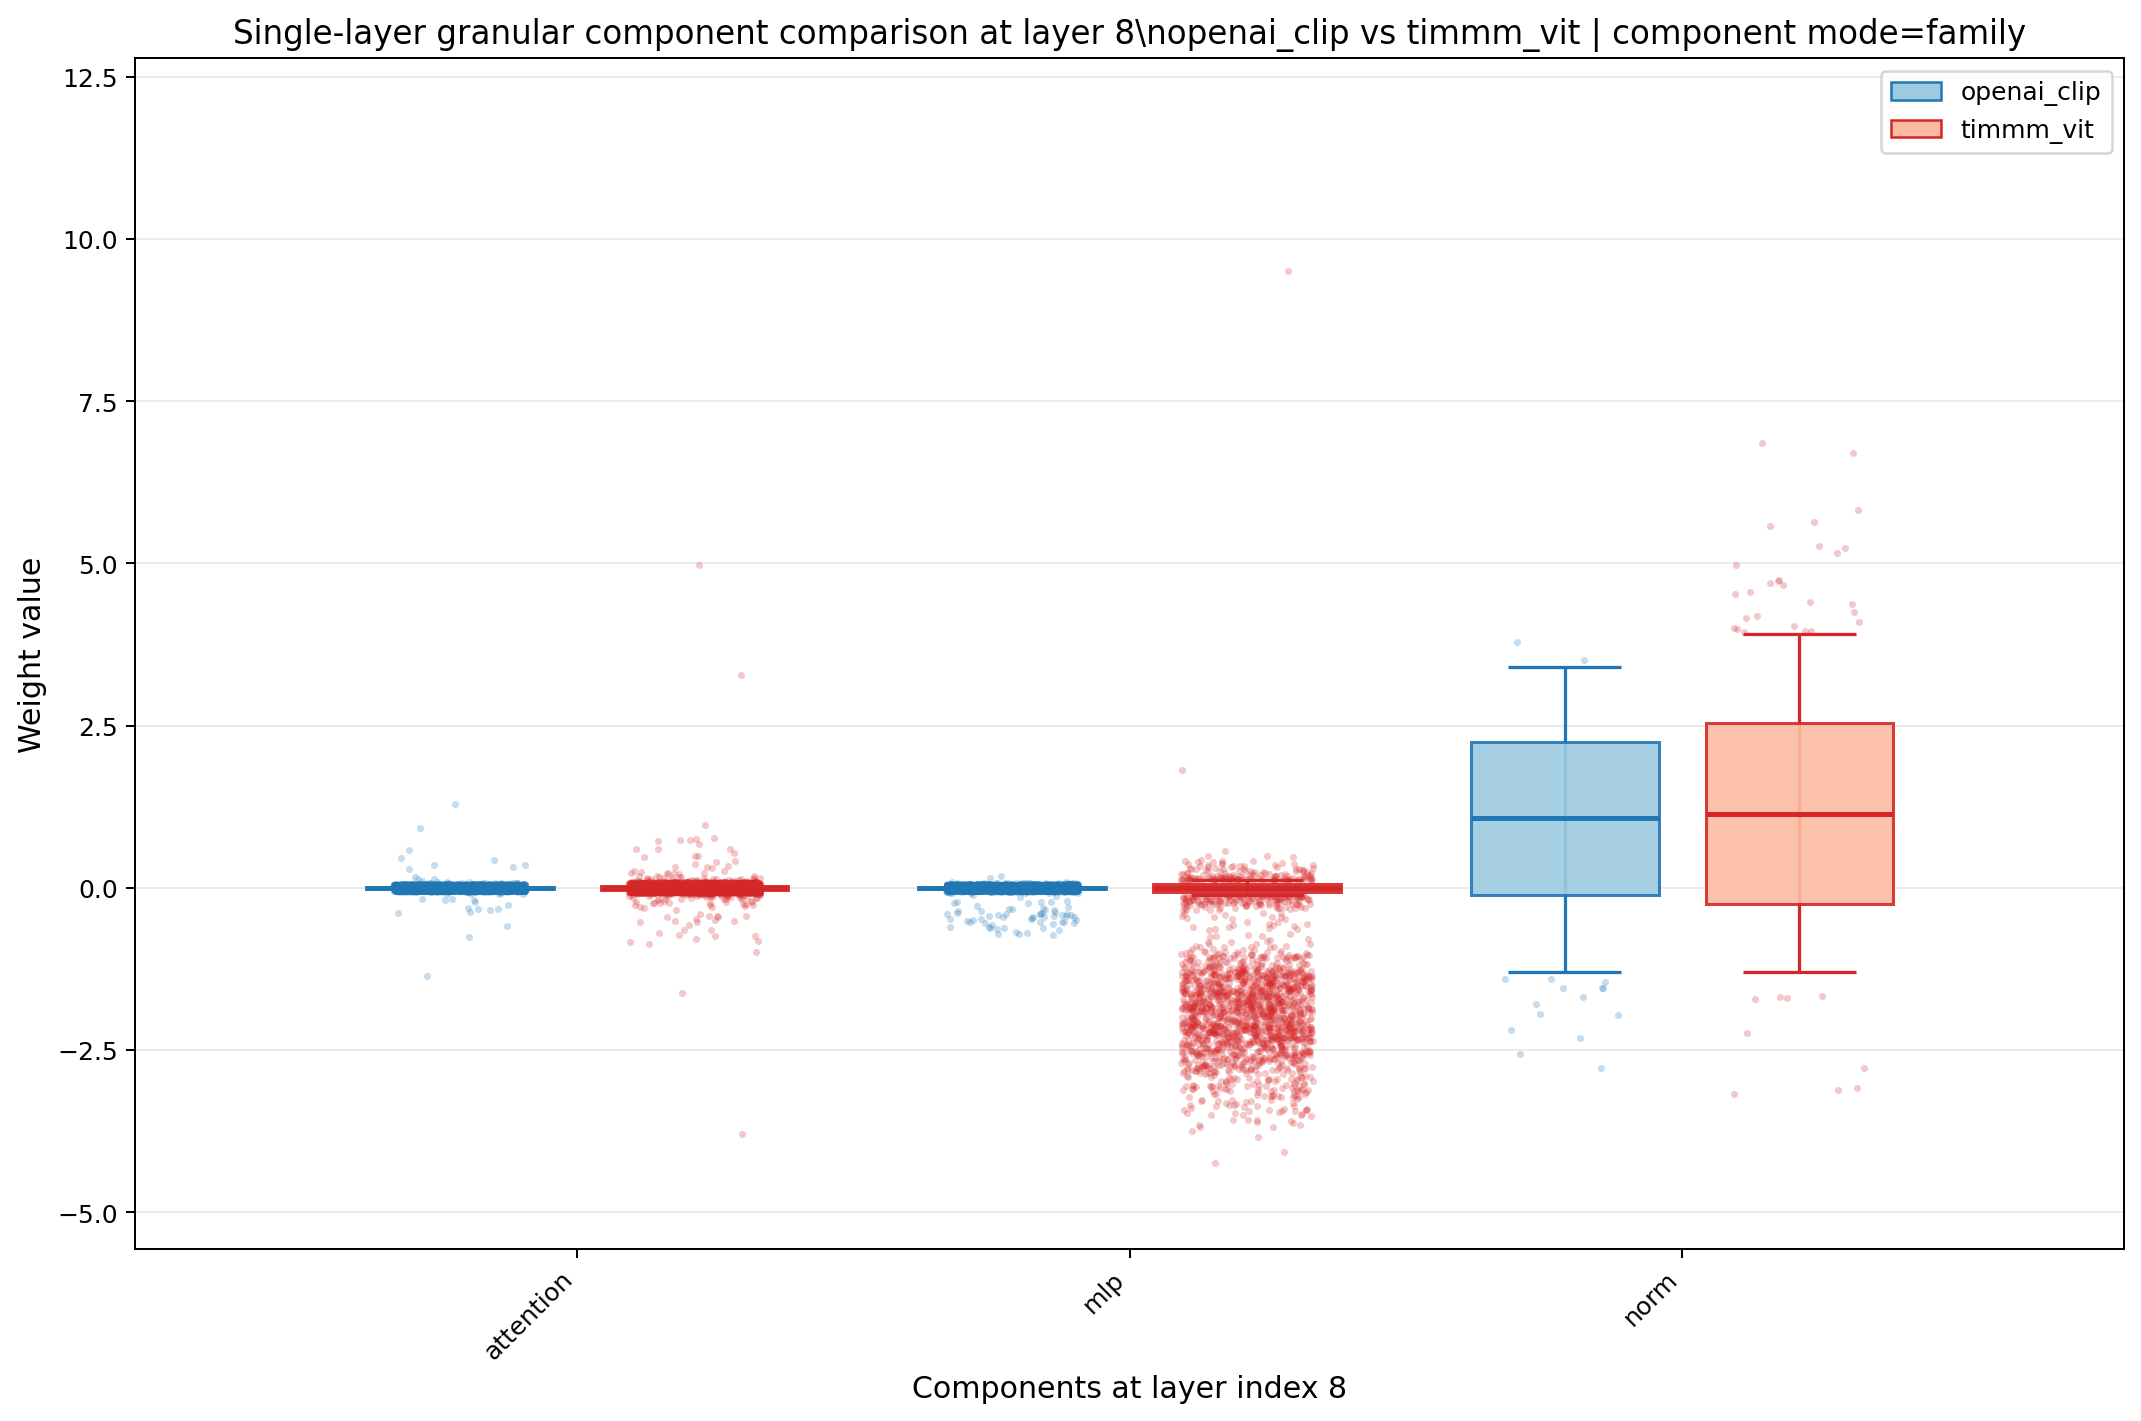

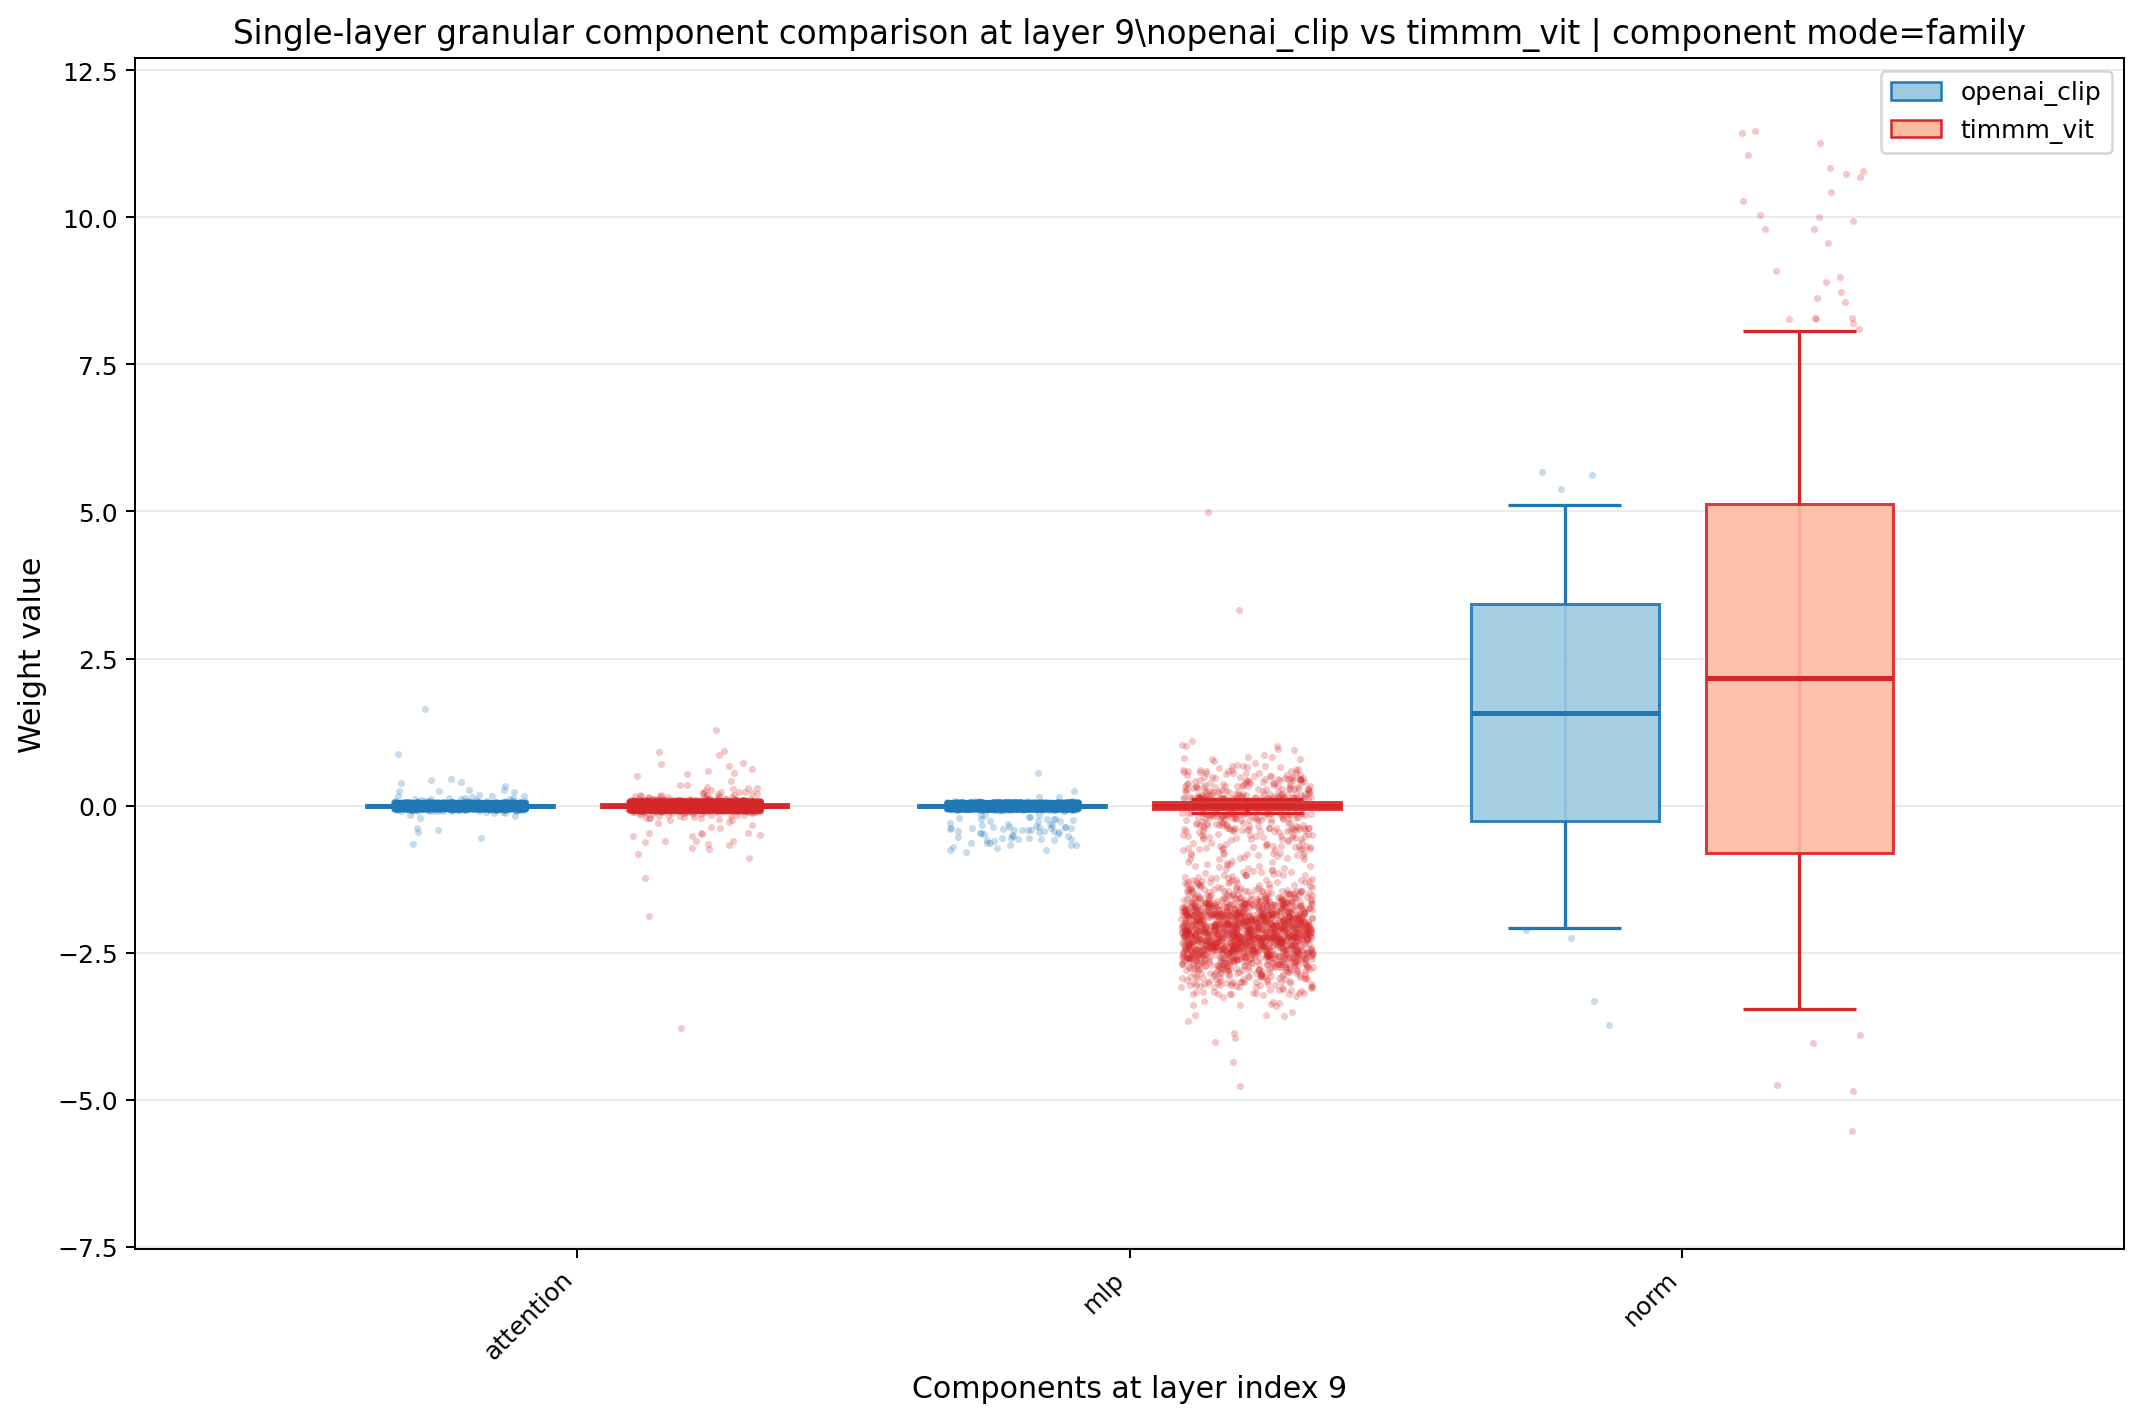

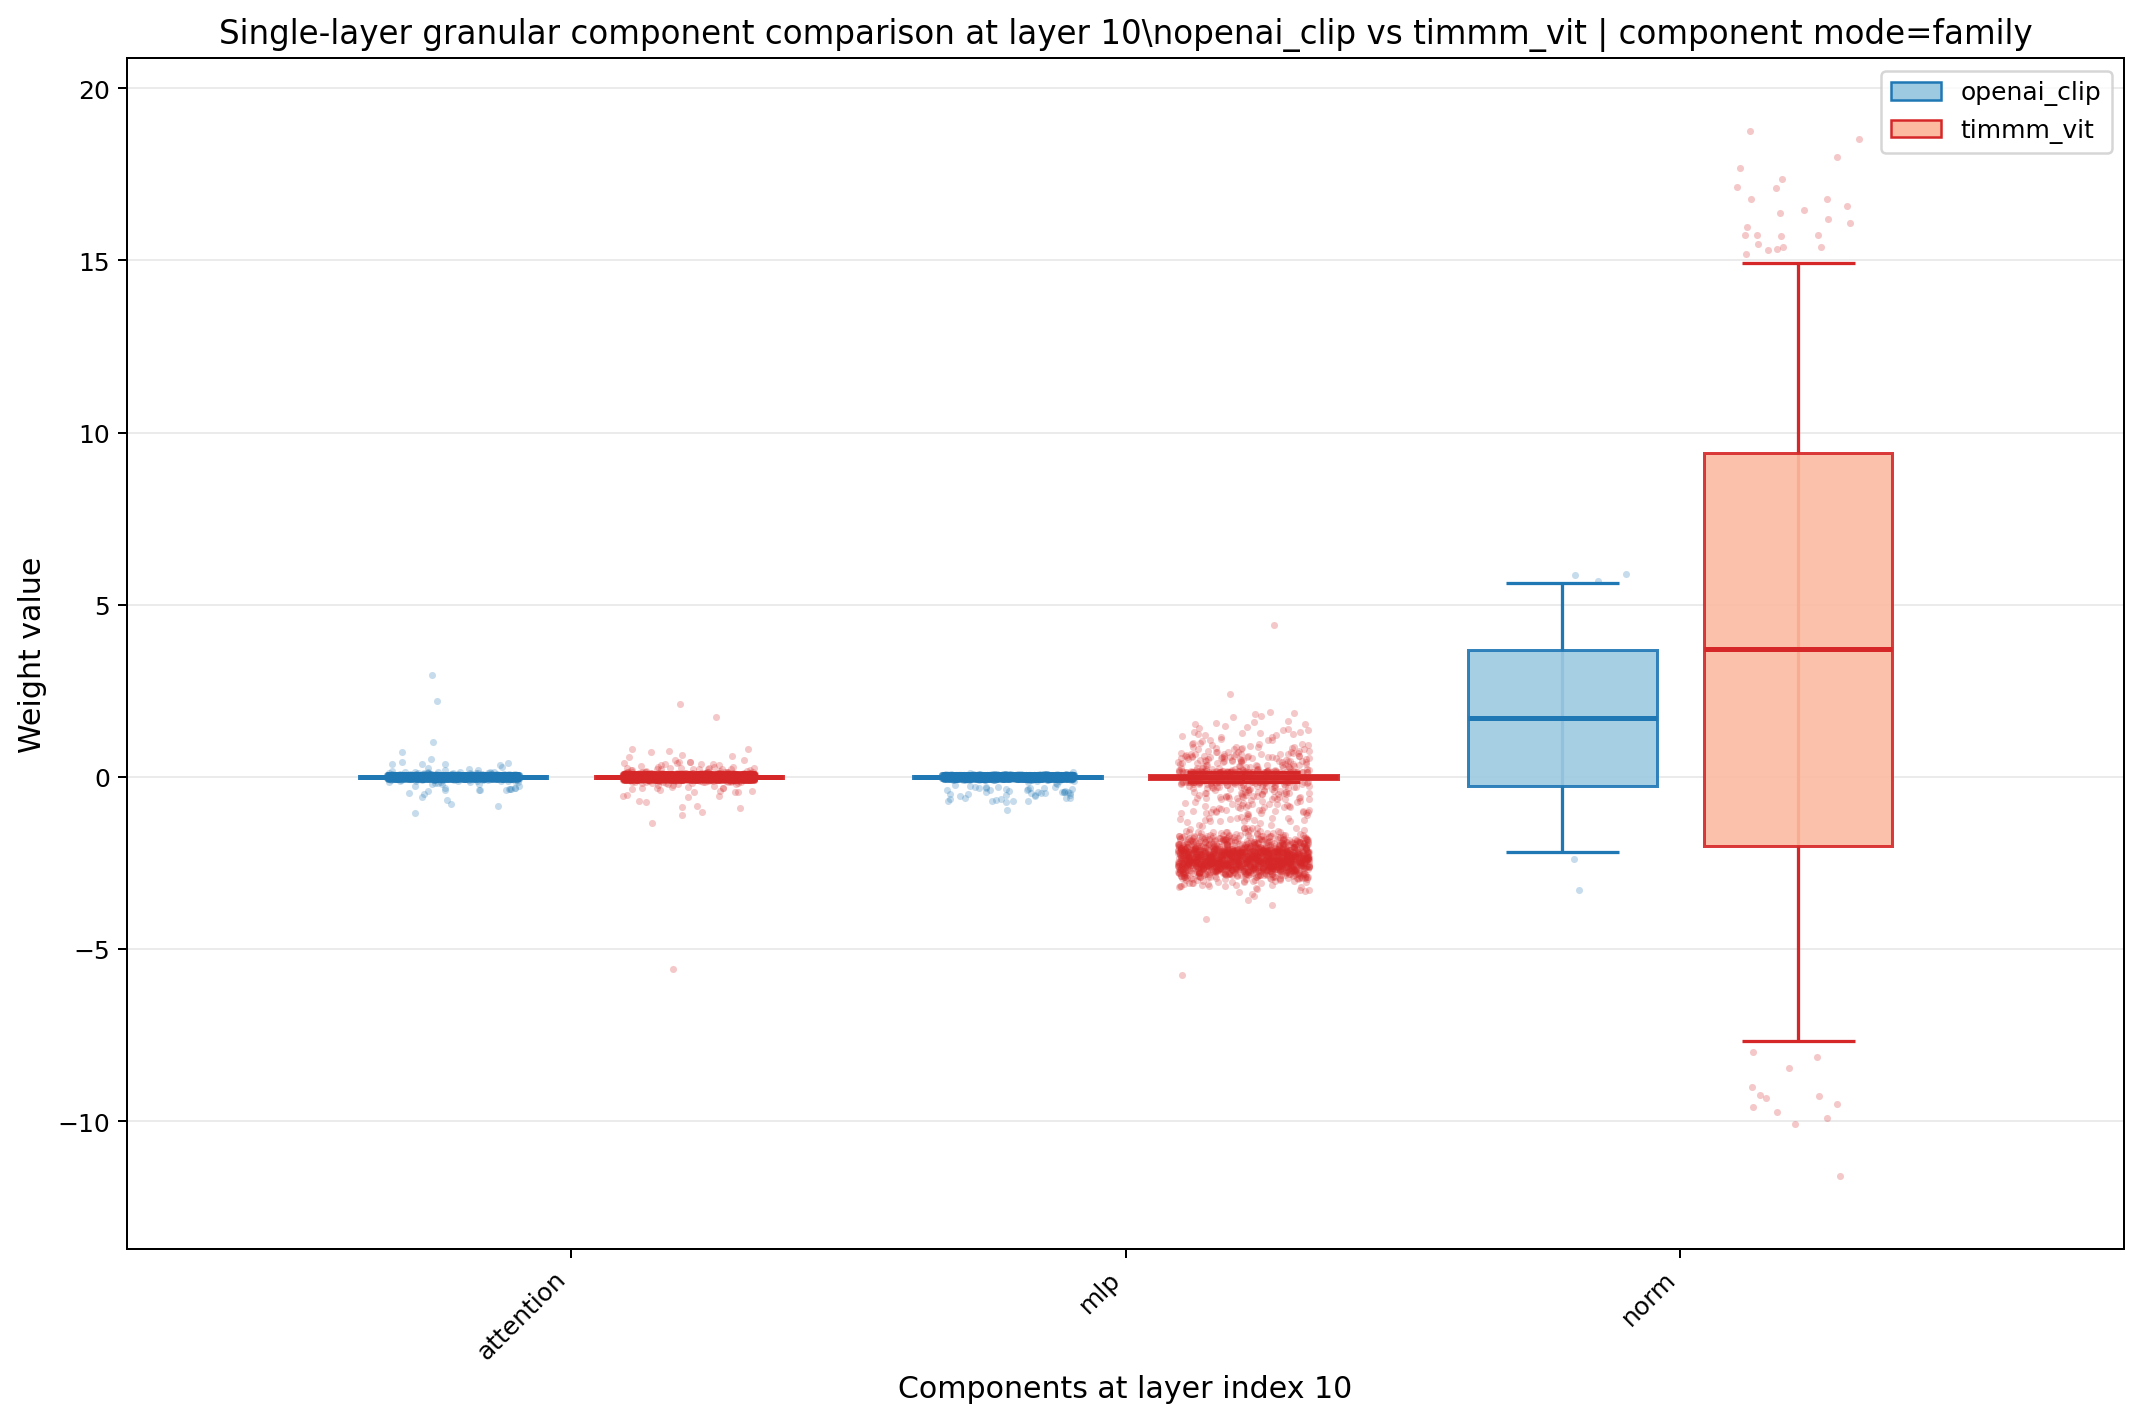

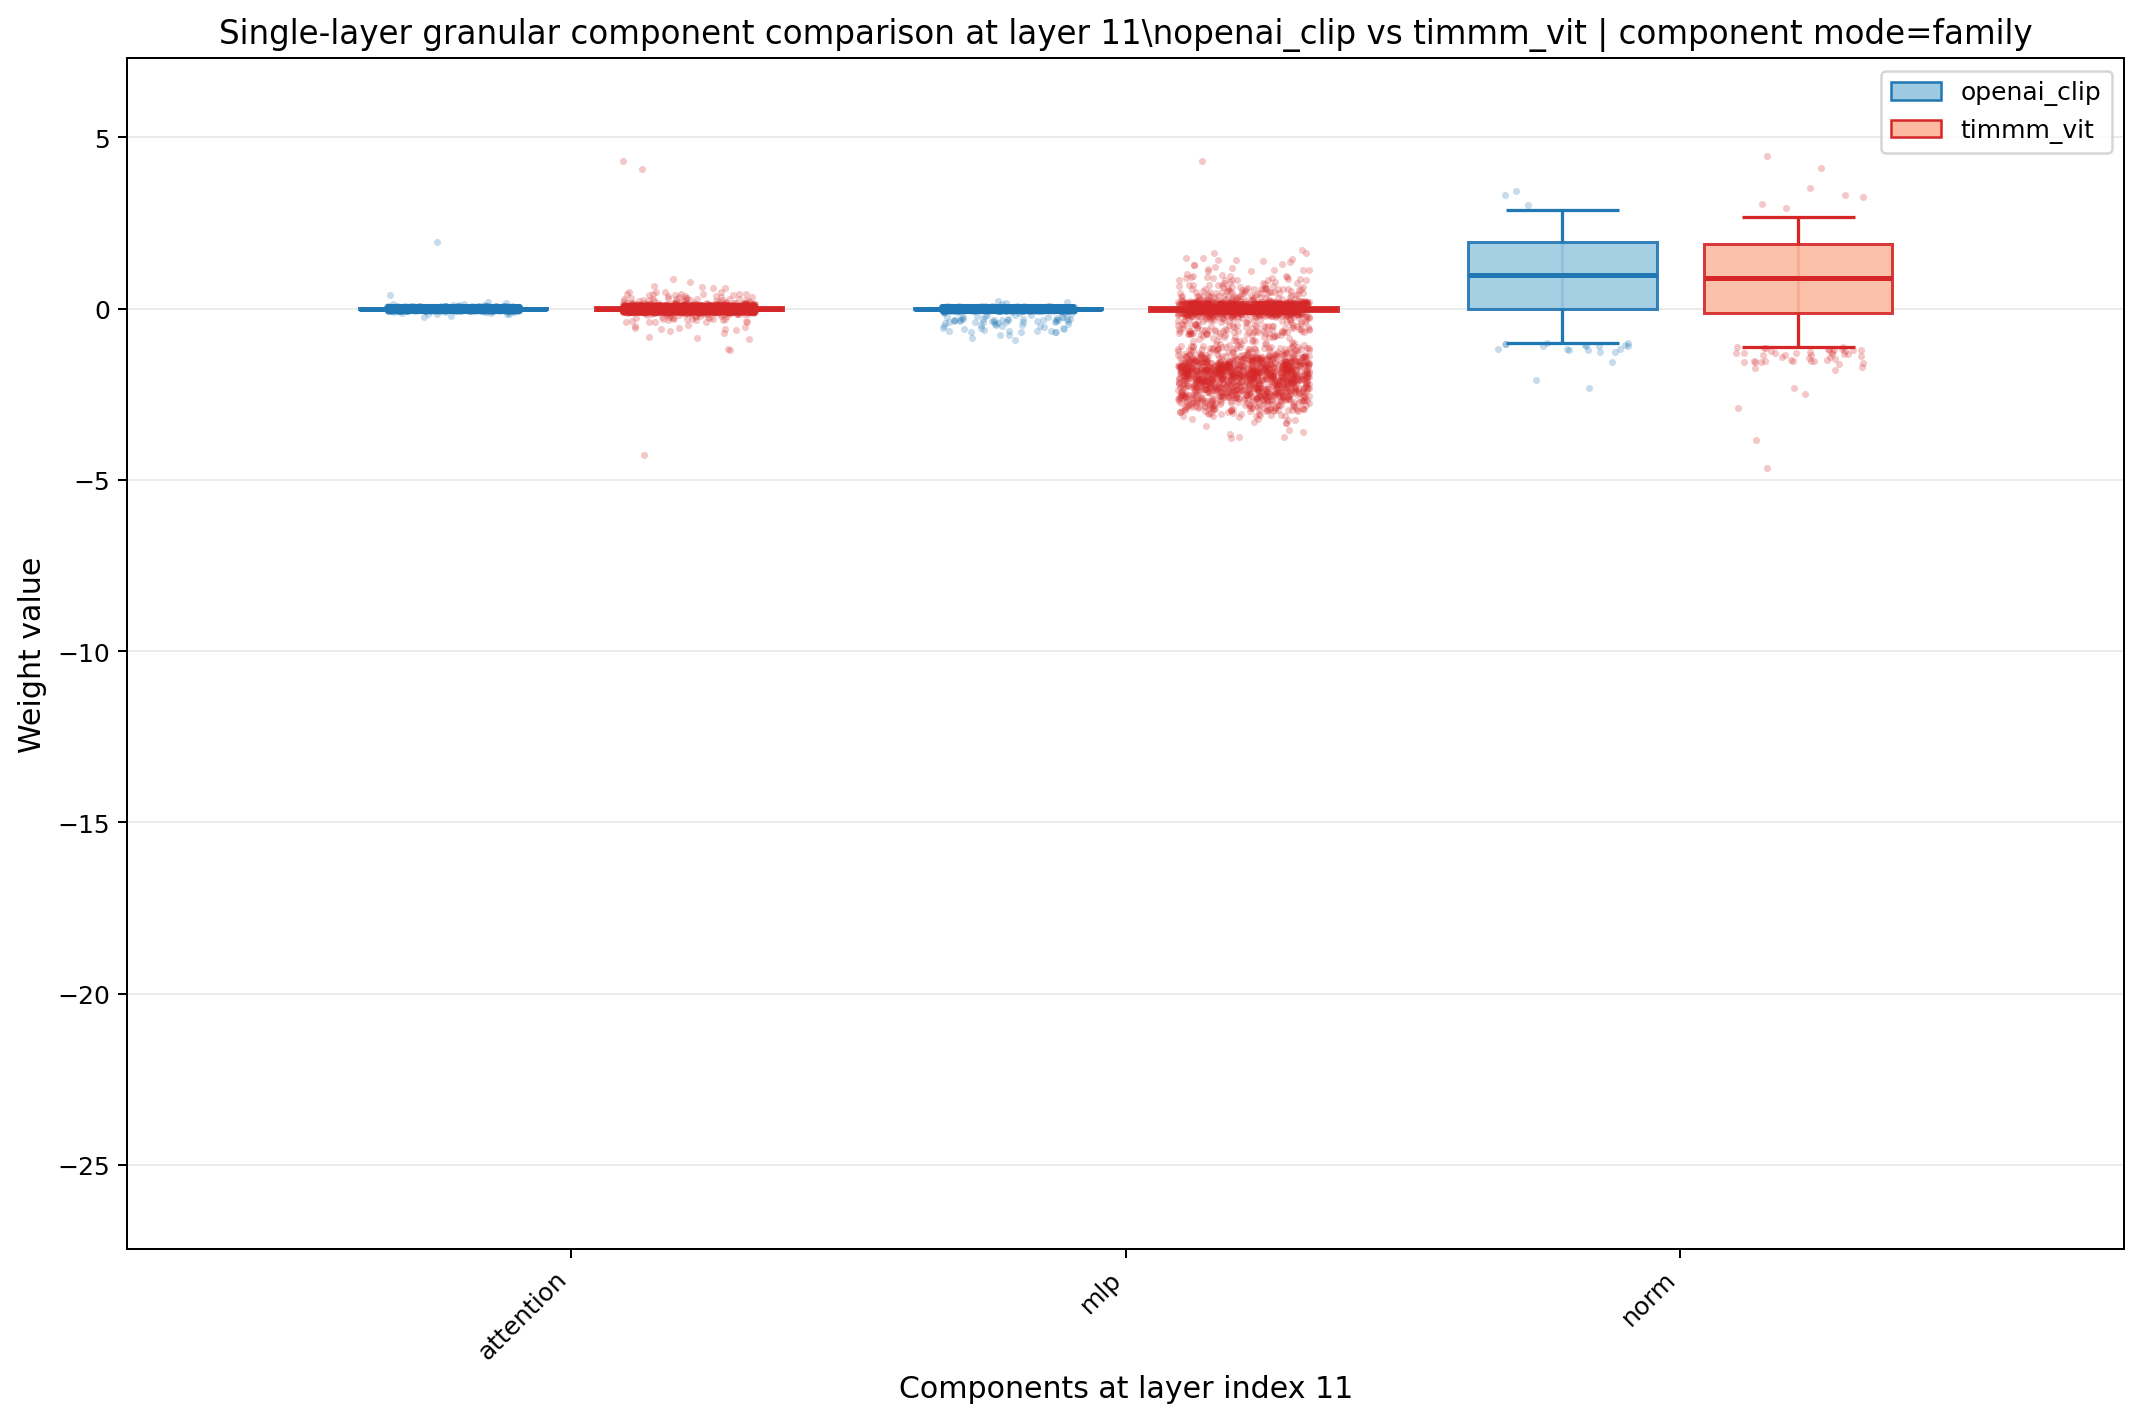

In [ ]:
for layer_idx in common_layer_indices:
    candidate_layers = sorted(set(component_stats_a) & set(component_stats_b))
    if not candidate_layers:
        raise RuntimeError("No common layer indices available for single-layer granular plotting.")
    if layer_idx not in candidate_layers:
        raise RuntimeError(
            f"Layer index {layer_idx} is not available. Choose one of: {candidate_layers}"
        )
    plot_component_candlesticks_for_layer(
        component_stats_a=component_stats_a,
        component_stats_b=component_stats_b,
        model_a_name=MODEL_A_LABEL,
        model_b_name=MODEL_B_LABEL,
        layer_idx=layer_idx,
    )